# Phyloseq analysis
- combo from Nikea https://github.com/nikeaulrich/DR_SCTLD/blob/main/DR_phyloseq.ipynb and my old https://github.com/brookewicz/CBC_metagenomics/blob/main/pstr/pstr_taxonomy_plots.ipynb

https://www.bioconductor.org/packages/release/bioc/html/phyloseq.html

Need to make a phyloseq object to run lefse \
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [1]:
getwd()

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld"

In [2]:
# see installation from 4Taxa_Trials in PSTR

In [3]:
# library(taxonomizr)
# this will get full taxonomy from NCBI 

In [4]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-5

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:s

## Upload Data

In [5]:
setwd("/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken")

### Taxonomy 

In [6]:
taxa = read.csv('otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,3021011,Vibrio sp. SCSIO 43137,S
2,2819098,Vibrio sp. SCSIO 43153,S
3,2819101,Vibrio sp. SCSIO 43136,S
4,2912314,Vibrio sp. JC009,S
5,2751178,Vibrio sp. B1FLJ16,S
6,2751176,Vibrio sp. B1ASS3,S


In [7]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [8]:
head(taxa)

,otuid,species
,<int>,<chr>
1,3021011,Vibrio sp. SCSIO 43137
2,2819098,Vibrio sp. SCSIO 43153
3,2819101,Vibrio sp. SCSIO 43136
4,2912314,Vibrio sp. JC009
5,2751178,Vibrio sp. B1FLJ16
6,2751176,Vibrio sp. B1ASS3


In [9]:
## add in full taxonomy from krakentools (2.1OTUtable)
taxa_full<-read.csv("txt_files/bracken_S.combined.mpa", sep = '\t') %>% select(1)
head(taxa_full)

,X.Classification
,<chr>
1,d__Bacteria
2,d__Bacteria|f__Candidatus_Chazhemtobacteraceae
3,d__Bacteria|f__Candidatus_Chazhemtobacteraceae|g__Candidatus_Chazhemtobacterium
4,d__Bacteria|f__Candidatus_Chazhemtobacteraceae|g__Candidatus_Chazhemtobacterium|s__Candidatus_Chazhemtobacterium_aquaticus
5,d__Bacteria|p__Candidatus_Bipolaricaulota
6,d__Bacteria|p__Candidatus_Bipolaricaulota|c__Candidatus_Bipolaricaulia


In [10]:
taxa_full[73,1]

[1] "d__Bacteria|k__Thermotogati|p__Synergistota|c__Synergistia|o__Synergistales|f__Aminithiophilaceae|g__Aminithiophilus|s__Aminithiophilus_ramosus"

In [11]:
taxonomy_full<-taxa_full %>%
  separate(
    col = X.Classification, 
    into = c("domain","kingdom", "phylum", "class", "order", "family", "genus", "species"), 
    sep = "\\|") %>%
  mutate(across(everything(), ~ gsub("^[a-z]__", "", .)))

Warning message:
“Expected 8 pieces. Missing pieces filled with `NA` in 7291 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


In [12]:
# filter for species-level matches
# and replace _ for spaces 
sp_full<-taxonomy_full %>%
    filter(!is.na(species)) %>%
    mutate(species = str_replace_all(species,"_"," "))
head(sp_full)

,domain,kingdom,phylum,class,order,family,genus,species
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Aminithiophilaceae,Aminithiophilus,Aminithiophilus ramosus
2,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Aminiphilaceae,Aminirod,Aminirod propionatiphilus
3,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Thermanaerovibrio,Thermanaerovibrio acidaminovorans
4,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Thermanaerovibrio,Thermanaerovibrio velox
5,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Aminomonas,Aminomonas paucivorans
6,Bacteria,Thermotogati,Synergistota,Synergistia,Synergistales,Synergistaceae,Cloacibacillus,Cloacibacillus evryensis


In [13]:
# merge with species taxa table
merged_taxa<-taxa %>%
    left_join(sp_full, by = "species")

In [14]:
unique(merged_taxa$domain)

[1] "Bacteria"  NA          "Eukaryota" "Archaea"

In [15]:
head(merged_taxa)

,otuid,species,domain,kingdom,phylum,class,order,family,genus
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3021011,Vibrio sp. SCSIO 43137,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2,2819098,Vibrio sp. SCSIO 43153,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
3,2819101,Vibrio sp. SCSIO 43136,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
4,2912314,Vibrio sp. JC009,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
5,2751178,Vibrio sp. B1FLJ16,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
6,2751176,Vibrio sp. B1ASS3,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio


In [16]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [17]:
# export - go back to 2.1 OTU table to use python to download full hierarchy for remaining missing spp
write.csv(merged_taxa, "txt_files/full_taxa_draft.csv")

In [18]:
merged_taxa %>%
    filter(is.na(genus)) %>%
    head(10)

,otuid,species,domain,kingdom,phylum,class,order,family,genus
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3395321,Vibrio sp. nBUS_14,NA,NA,NA,NA,NA,NA,NA
2,3398215,Neptuniibacter sp. SY11_33,NA,NA,NA,NA,NA,NA,NA
3,3398212,Neptuniibacter sp. QD48_55,NA,NA,NA,NA,NA,NA,NA
4,3398206,Neptuniibacter sp. PT8_73,NA,NA,NA,NA,NA,NA,NA
5,3398210,Neptuniibacter sp. QD37_6,NA,NA,NA,NA,NA,NA,NA
6,2724896,Marinicellulosiphila megalodicopiae,NA,NA,NA,NA,NA,NA,NA
7,134287,secondary endosymbiont of Heteropsylla cubana,NA,NA,NA,NA,NA,NA,NA
8,1199245,secondary endosymbiont of Ctenarytaina eucalypti,NA,NA,NA,NA,NA,NA,NA
9,2675772,Enterobacteriaceae endosymbiont of Donacia bicoloricornis,NA,NA,NA,NA,NA,NA,NA


In [19]:
# import fully filled in taxonomy table (from 2.1OTUtable using python)
taxonomy_filled<-read.csv("txt_files/taxonomy_filled.csv")

In [20]:
str(taxonomy_filled)

'data.frame':	15891 obs. of  9 variables:
 $ otuid  : int  3021011 2819098 2819101 2912314 2751178 2751176 2785746 3391579 3137398 2908646 ...
 $ species: chr  "Vibrio sp. SCSIO 43137" "Vibrio sp. SCSIO 43153" "Vibrio sp. SCSIO 43136" "Vibrio sp. JC009" ...
 $ domain : chr  "Bacteria" "Bacteria" "Bacteria" "Bacteria" ...
 $ kingdom: chr  "Pseudomonadati" "Pseudomonadati" "Pseudomonadati" "Pseudomonadati" ...
 $ phylum : chr  "Pseudomonadota" "Pseudomonadota" "Pseudomonadota" "Pseudomonadota" ...
 $ class  : chr  "Gammaproteobacteria" "Gammaproteobacteria" "Gammaproteobacteria" "Gammaproteobacteria" ...
 $ order  : chr  "Vibrionales" "Vibrionales" "Vibrionales" "Vibrionales" ...
 $ family : chr  "Vibrionaceae" "Vibrionaceae" "Vibrionaceae" "Vibrionaceae" ...
 $ genus  : chr  "Vibrio" "Vibrio" "Vibrio" "Vibrio" ...


In [21]:
# make the index the otu ids
row.names(taxonomy_filled) <- taxonomy_filled$otuid
taxonomy_filled$otuid <- NULL
head(taxonomy_filled)

,species,domain,kingdom,phylum,class,order,family,genus
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
3021011,Vibrio sp. SCSIO 43137,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2819098,Vibrio sp. SCSIO 43153,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2819101,Vibrio sp. SCSIO 43136,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2912314,Vibrio sp. JC009,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2751178,Vibrio sp. B1FLJ16,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
2751176,Vibrio sp. B1ASS3,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio


In [22]:
# reorder columns in taxonomic order
taxonomy_filled <- taxonomy_filled %>%
  select(domain, kingdom, phylum, class, order, family, genus, species)

In [23]:
unique(taxonomy_filled$domain)
unique(taxonomy_filled$kingdom)

[1] "Bacteria"     "Eukaryota"    "Archaea"      "Virus"        "Unclassified"

[1] "Pseudomonadati"    "Bacillati"         "Fusobacteriati"   
 [4] "Thermotogati"      "Unclassified"      "Fungi"            
 [7] "Methanobacteriati" "Thermoproteati"    "Promethearchaeati"
[10] "Nanobdellati"      "Heunggongvirae"    "Bamfordvirae"     
[13] "Orthornavirae"     "Pararnavirae"      "Shotokuvirae"     
[16] "Zilligvirae"       "Viridiplantae"     "Helvetiavirae"    
[19] "Loebvirae"         "Trapavirae"        "Abadenavirae"     
[22] "Sangervirae"

In [24]:
# fill in unclassified
taxonomy_filled<-taxonomy_filled %>%
    mutate(kingdom = case_when(domain == "Unclassified" ~ kingdom, 
                                kingdom == "Unclassified" ~ paste0("Unclassified_",domain), 
                                TRUE ~ kingdom)) %>%
    mutate(phylum = case_when(kingdom == "Unclassified" ~ phylum, 
                                phylum == "Unclassified" ~ paste0("Unclassified_",kingdom), 
                                TRUE ~ phylum)) %>%
    mutate(class = case_when(phylum == "Unclassified" ~ class, 
                                class == "Unclassified" ~ paste0("Unclassified_",phylum), 
                                TRUE ~ class)) %>%
    mutate(order = case_when(class == "Unclassified" ~ order, 
                                order == "Unclassified" ~ paste0("Unclassified_",class), 
                                TRUE ~ order)) %>%
    mutate(family = case_when(order == "Unclassified" ~ family, 
                                family == "Unclassified" ~ paste0("Unclassified_",order), 
                                TRUE ~ family)) %>%
    mutate(genus = case_when(family == "Unclassified" ~ genus, 
                                genus == "Unclassified" ~ paste0("Unclassified_",family), 
                                TRUE ~ genus))

In [25]:
taxonomy_filled<-taxonomy_filled %>%
    mutate(across(everything(), ~ gsub("^[a-z]__", "", .)))

In [26]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxonomy_filled)

# check structure
str(taxonomy)    

 chr [1:15891, 1:8] "Bacteria" "Bacteria" "Bacteria" "Bacteria" "Bacteria" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:15891] "3021011" "2819098" "2819101" "2912314" ...
  ..$ : chr [1:8] "domain" "kingdom" "phylum" "class" ...


### OTU Table

In [27]:
#read in normalized otu table
otu = read.csv('otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X052022_BEL_CBC_T1_10_PSTR,X052022_BEL_CBC_T1_11_PSTR,X052022_BEL_CBC_T1_12_MCAV,X052022_BEL_CBC_T1_13_MCAV,X052022_BEL_CBC_T1_1_PAST,X052022_BEL_CBC_T1_34_PAST,X052022_BEL_CBC_T1_35_OANN,X052022_BEL_CBC_T1_39_MCAV,X052022_BEL_CBC_T1_40_MCAV,⋯,X122022_BEL_CBC_T4_38_MCAV,X122022_BEL_CBC_T4_4_PSTR,X122022_BEL_CBC_T4_5_MCAV,X122022_BEL_CBC_T4_6_MCAV,X122022_BEL_CBC_T4_8_PSTR,X122022_BEL_CBC_T4_9_OFAV,X7_11_Neg,X7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198942.472
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7732.497
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61061.190
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17074.439
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20072.270
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18651.218


In [28]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X052022_BEL_CBC_T1_10_PSTR,X052022_BEL_CBC_T1_11_PSTR,X052022_BEL_CBC_T1_12_MCAV,X052022_BEL_CBC_T1_13_MCAV,X052022_BEL_CBC_T1_1_PAST,X052022_BEL_CBC_T1_34_PAST,X052022_BEL_CBC_T1_35_OANN,X052022_BEL_CBC_T1_39_MCAV,X052022_BEL_CBC_T1_40_MCAV,⋯,X122022_BEL_CBC_T4_38_MCAV,X122022_BEL_CBC_T4_4_PSTR,X122022_BEL_CBC_T4_5_MCAV,X122022_BEL_CBC_T4_6_MCAV,X122022_BEL_CBC_T4_8_PSTR,X122022_BEL_CBC_T4_9_OFAV,X7_11_Neg,X7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198942.472
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7732.497
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61061.190
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17074.439
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20072.270
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18651.218


[1] 15894   224

In [29]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198942.472
2,2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7732.497
3,2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61061.190
4,2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17074.439
5,2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20072.270
6,2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18651.218


In [30]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
# column_list <- readLines("DR_column_order.txt")
# otu_table <- otu_table[, column_list]
# head(otu_table)

In [31]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3021011,23887.8267,108.23239,2959.21739,0.00000,148.8358,34.00636,237.959,13396.95278,537.50643,0.0000,⋯,0.0000,17.46868,0.00000,51.64680,23.19476,176.82509,0.000000,0,0.00000,198942.472
2819098,3661.7429,359.79957,49.47990,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,0.0000,⋯,0.0000,0.00000,0.00000,33.68270,0.00000,42.40193,1.772594,0,1.60177,7732.497
2819101,468.5301,353.94917,92.57530,0.00000,0.0000,32.21655,840.451,141.47182,0.00000,1251.3442,⋯,1156.4878,112.75237,1031.86757,368.26416,132.92380,378.00873,0.000000,0,0.00000,61061.190
2912314,178.4018,67.27959,124.49782,0.00000,176.7425,35.79617,0.000,282.94364,76.78663,0.0000,⋯,141.0351,19.05674,61.98498,46.03302,15.16580,63.15182,0.000000,0,0.00000,17074.439
2751178,163.9855,172.58678,44.69152,91.32361,0.0000,41.16559,0.000,64.30537,0.00000,166.1942,⋯,131.6328,50.81797,69.27733,152.69490,67.80006,128.10797,0.000000,0,0.00000,20072.270
2751176,349.5955,3881.74003,162.80484,0.00000,0.0000,0.00000,0.000,0.00000,0.00000,0.0000,⋯,0.0000,0.00000,0.00000,267.21607,23.19476,251.70510,0.000000,0,0.00000,18651.218


In [32]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,554927.0000,341857.0000,626517.000,153301.0000,107501.0000,558719.0000,197513.0000,233262.000,130231.00,102290.0000,⋯,212713.0000,1259397.00,274260.000,890665.0000,1120943.000,1.108440e+06,1.636020e+07,4494966.00,1.061326e+07,294861214
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,40185.6022,219368.48,28706.337,7715.5833,269447.242,2.435856e+02,3.674441e+05,308665.07,1.248429e+04,17997693
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,12777.7804,93354.20,2140.305,191.9914,9283.255,1.101548e+03,1.559150e+03,6292.15,6.112587e+05,4938596
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,42564.3943,15603.50,43342.084,57275.1820,17986.642,3.924073e+04,2.506082e+00,0.00,3.109318e+00,3624787
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,404.3006,42190.03,21403.048,8595.8245,62173.545,6.946700e+01,1.412656e+05,111969.70,2.167101e+01,2672574
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,13370.1278,24553.02,5079.122,798.2799,24815.713,8.480387e+01,2.769648e+04,39314.87,4.633826e+03,2465159


In [33]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]

# remove sum col
otus_sorted$Sum <- NULL

head(otus_sorted)
dim (otus_sorted)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,9859.4883,40185.6022,219368.476,28706.337,7715.5833,269447.242,243.58558,3.674441e+05,308665.07,1.248429e+04
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,404.6615,12777.7804,93354.200,2140.305,191.9914,9283.255,1101.54812,1.559150e+03,6292.15,6.112587e+05
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,55624.4130,42564.3943,15603.499,43342.084,57275.1820,17986.642,39240.73473,2.506082e+00,0.00,3.109318e+00
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,4769.4066,404.3006,42190.032,21403.048,8595.8245,62173.545,69.46700,1.412656e+05,111969.70,2.167101e+01
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,1987.6769,13370.1278,24553.020,5079.122,798.2799,24815.713,84.80387,2.769648e+04,39314.87,4.633826e+03
1590,470.3321,558.7131,21148.668,14357.3754,11088.2689,2627.4388,460.7292,10190.258,21070.25,479.0302,⋯,1325.9663,10751.5761,6156.915,3121.126,799.4027,6145.718,490.77983,1.388436e+04,26322.11,1.858421e+04


[1] 15893   222

In [34]:
# Convert to matrix
otus_norm=as.matrix(otus_sorted)
head(otus_norm)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
2057741,646.9319,912.6623,179529.047,74559.2005,179021.5905,14756.9709,6060.3606,105130.711,325475.50,2062.7627,⋯,9859.4883,40185.6022,219368.476,28706.337,7715.5833,269447.242,243.58558,3.674441e+05,308665.07,1.248429e+04
1747,264.8997,857.0835,19008.263,5838.1876,63990.1024,2822.5280,678.4364,2958.047,11295.31,918.9559,⋯,404.6615,12777.7804,93354.200,2140.305,191.9914,9283.255,1101.54812,1.559150e+03,6292.15,6.112587e+05
2066072,33593.6078,29992.0727,12615.779,1245.9149,976.7351,141.3949,12282.7358,22579.760,31244.48,18995.0142,⋯,55624.4130,42564.3943,15603.499,43342.084,57275.1820,17986.642,39240.73473,2.506082e+00,0.00,3.109318e+00
1929291,153.1733,175.5120,164.401,182.6472,111.6269,1583.9805,222.7701,39916.489,0.00,0.0000,⋯,4769.4066,404.3006,42190.032,21403.048,8595.8245,62173.545,69.46700,1.412656e+05,111969.70,2.167101e+01
1325120,88.2999,117.0080,30699.885,21461.0472,21562.5901,2040.3817,531.6106,31188.106,17660.93,215.0748,⋯,1987.6769,13370.1278,24553.020,5079.122,798.2799,24815.713,84.80387,2.769648e+04,39314.87,4.633826e+03
1590,470.3321,558.7131,21148.668,14357.3754,11088.2689,2627.4388,460.7292,10190.258,21070.25,479.0302,⋯,1325.9663,10751.5761,6156.915,3121.126,799.4027,6145.718,490.77983,1.388436e+04,26322.11,1.858421e+04


#### OTU Raw

In [35]:
#read in raw otu table
otu_raw = read.csv("otu_table_species.csv",header=TRUE)
# remove prefix and suffixes from sampleIDs
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), ".kreport2_S.bracken_num", "")
colnames(otu_raw)<-str_replace_all(colnames(otu_raw), "X", "")

In [36]:
head(otu_raw)

,taxonomy_id,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,3021011,13256,37,1854,0,16,19,47,3125,70,⋯,11,0,22,0,46,26,196,0,0,0
2,2819098,2032,123,31,0,0,0,0,0,0,⋯,0,0,0,0,30,0,47,29,0,17
3,2819101,260,121,58,0,0,18,166,33,0,⋯,154,246,142,283,328,149,419,0,0,0
4,2912314,99,23,78,0,19,20,0,66,10,⋯,14,30,24,17,41,17,70,0,0,0
5,2751178,91,59,28,14,0,23,0,15,0,⋯,47,28,64,19,136,76,142,0,0,0
6,2751176,194,1327,102,0,0,0,0,0,0,⋯,0,0,0,0,238,26,279,0,0,0


In [37]:
# rename first col as otu
names(otu_raw)[1] <- "otu"

# make the index the otus
row.names(otu_raw) <- otu_raw$otu
otu_raw$otu <- NULL

# sort by most abundant OTUs
otu_raw_sorted <- otu_raw[order(rowSums(otu_raw), decreasing = TRUE), ]

# Convert to matrix
otus_raw=as.matrix(otu_raw_sorted)
head(otus_raw)

,052022_BEL_CBC_T1_10_PSTR,052022_BEL_CBC_T1_11_PSTR,052022_BEL_CBC_T1_12_MCAV,052022_BEL_CBC_T1_13_MCAV,052022_BEL_CBC_T1_1_PAST,052022_BEL_CBC_T1_34_PAST,052022_BEL_CBC_T1_35_OANN,052022_BEL_CBC_T1_39_MCAV,052022_BEL_CBC_T1_40_MCAV,052022_BEL_CBC_T1_41_OANN,⋯,122022_BEL_CBC_T4_36_PSTR,122022_BEL_CBC_T4_38_MCAV,122022_BEL_CBC_T4_4_PSTR,122022_BEL_CBC_T4_5_MCAV,122022_BEL_CBC_T4_6_MCAV,122022_BEL_CBC_T4_8_PSTR,122022_BEL_CBC_T4_9_OFAV,7_11_Neg,7_3_Neg,Negative_extract_11.2.24
2057741,359,312,112478,11430,19245,8245,1197,24523,42387,211,⋯,3874,8548,276272,7873,6872,302035,270,6011460,1387439,132499
1747,147,293,11909,895,6879,1577,134,690,1471,94,⋯,159,2718,117570,587,171,10406,1221,25508,28283,6487447
1929291,85,60,103,28,12,885,44,9311,0,0,⋯,1874,86,53134,5870,7656,69693,77,2311134,503300,230
172371,11,10,27,0,0,51,10,0,0,0,⋯,0,0,24,0,20,18,19,299,54,19
1325120,49,40,19234,3290,2318,1140,105,7275,2300,22,⋯,781,2844,30922,1393,711,27817,94,453120,176719,49180
3101350,48,66,59,0,0,272,58,11,0,11,⋯,26,44,298,39,43,42,60,404,88,11


In [38]:
# look what most abundant is 
indices<-c("2057741", "1747", "1929291","1325120","3101350")
taxonomy_filled[indices,]
# cutibacterium is human skin microbe but the rest seem ok

,domain,kingdom,phylum,class,order,family,genus,species
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2057741,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium,Bradyrhizobium sp. SK17
1747,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Cutibacterium,Cutibacterium acnes
1929291,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Reyranellaceae,Reyranella,Reyranella sp.
1325120,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium,Bradyrhizobium sp. CCBAU 53421
3101350,Bacteria,Pseudomonadati,Gemmatimonadota,Gemmatimonadia,Candidatus_Palauibacterales,Candidatus_Palauibacteraceae,Candidatus_Palauibacter,Candidatus Palauibacter sp.


### Metadata

In [39]:
getwd()

[1] "/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/taxonomy/kraken2_pluspf/bracken"

In [40]:
#read in metadata
# in pstr version i directly uploaded cbc samples and cbc colony data
# going to try my already merged meta+sampleid table that I made in read_counts..

metadata=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/reads_meta.csv', header=TRUE)

# index the SampleIDs and remove raw read counts
metadata$raw <- NULL
metadata$trimmed <- NULL
metadata$pct_yield <- NULL

# row.names(metadata) <- metadata$sampleid
# metadata$sampleid <- NULL
head(metadata)

,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,052022_BEL_CBC_T1_10_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,10,Diseased_Margin,T1_4_PSTR,52022_PSTR_Diseased_Margin
2,052022_BEL_CBC_T1_11_PSTR,52022,5/21/22,CBC30N,1,4,PSTR,11,Diseased_Tissue,T1_4_PSTR,52022_PSTR_Diseased_Tissue
3,052022_BEL_CBC_T1_12_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,12,Diseased_Margin,T1_8_MCAV,52022_MCAV_Diseased_Margin
4,052022_BEL_CBC_T1_13_MCAV,52022,5/21/22,CBC30N,1,8,MCAV,13,Diseased_Tissue,T1_8_MCAV,52022_MCAV_Diseased_Tissue
5,052022_BEL_CBC_T1_1_PAST,52022,5/21/22,CBC30N,1,2,PAST,1,Healthy,T1_2_PAST,52022_PAST_Healthy
6,052022_BEL_CBC_T1_34_PAST,52022,5/21/22,CBC30N,1,21,PAST,34,Healthy,T1_21_PAST,52022_PAST_Healthy


In [41]:
# create list of colony IDs in sample set 
colony_list<-unique(metadata$colony_id)
# NAs are all negative controls

In [42]:
length(unique(metadata$sampleid))

[1] 222

In [43]:
unique(metadata$Month_year)
# what months do we need conditions from colonydata

[1]  52022  62019 102019 122022     NA

In [44]:
metadata %>%
    filter(is.na(Month_year))

sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
7_11_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
7_3_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
Negative_extract_11-2-24,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative


In [45]:
# upload colony data to add Resistant vs Susceptible category

colony=read.csv('/scratch4/workspace/brooke_sienkiewicz_student_uml_edu-bel_raw/CBC_ColonyData.csv',header=TRUE)

In [46]:
# add colony id and filter for target colonies
colony$colony_id<-paste0("T", colony$TransectNum, "_", colony$NewTagNum,"_",colony$Species)

# remove cols
colony_filtered<-colony %>%
    select(colony_id, Date_InitialTag, Date_DocumentedDisease, Date_DocumentedMortality, X062019_Condition,X102019_Condition, X052022_Condition,X122022_Condition,X092023_Condition)

# filter for target samples' colony IDs
colony_filtered<-colony_filtered %>%
    filter(colony_id %in% colony_list)

In [47]:
length(unique(colony_filtered$colony_id))
length(colony_list)

[1] 112

[1] 114

In [48]:
setequal(metadata$colony_id, colony_filtered$colony_id)

[1] FALSE

In [49]:
missing_in_metadat <- setdiff(colony_filtered$colony_id, metadata$colony_id)
missing_in_metadat # none missing from metadata
length(missing_in_metadat)


character(0)

[1] 0

In [50]:
# IDs in df2 that are missing from df1
missing_in_colony <- setdiff(metadata$colony_id, colony$colony_id)
missing_in_colony 
# only NAs and an accidental sample are missing in colony data (negative controls - no colony ID)

[1] "T2_AS_OANN" NA

In [51]:
# merge sample and colony data 
sample_colony=merge(metadata, colony_filtered, by="colony_id")

In [52]:
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,group,Date_InitialTag,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,T1_12_PSTR,052022_BEL_CBC_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,52022_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
2,T1_12_PSTR,102019_BEL_CBC_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,102019_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
3,T1_12_PSTR,122022_BEL_CBC_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,122022_PSTR_Healthy,10/15/19,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy
4,T1_13_PAST,122022_BEL_CBC_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,122022_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy
5,T1_13_PAST,052022_BEL_CBC_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,52022_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy
6,T1_13_PAST,062019_BEL_CBC_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,62019_PAST_Healthy,06/24/19,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy


In [53]:
# view AS
metadata %>%
    filter(colony_id == 'T2_AS_OANN')
# hmm notes in cbc samples nor accidental sample tracker doesnt tell me what colony its supposed to be
# will have to remove

metadata %>%
    filter(is.na(colony_id))

sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
122022_BEL_CBC_T2_107_OANN,122022,12/4/22,SR30N,2,AS,ORBI,107,Diseased_Tissue,T2_AS_OANN,122022_OANN_Diseased_Tissue


sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,colony_id,group
<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
7_11_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
7_3_Neg,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative
Negative_extract_11-2-24,NA,NA,NA,NA,NA,NEG,NA,NA,NA,Negative


In [54]:
# add labels to negative and remove accidental sample
sample_colony<-sample_colony %>%
    filter(NewTagNum != "AS") %>%
    mutate(colony_id = case_when(
        sampleid == "7_3_Neg" ~ "Neg1",
        sampleid == "7_11_Neg" ~ "Neg2",
        sampleid == "Negative_extract_11-2-24" ~ "Neg3",
        TRUE ~ colony_id
    ))

In [55]:
sample_colony<-sample_colony %>%
    mutate(RS = case_when(
        X052022_Condition=="Diseased" ~ "Susceptible",
        X052022_Condition=="Dead" ~ "Susceptible",
        X122022_Condition=="Healthy" ~ "Resistant",
        X122022_Condition=="Diseased" ~ "Susceptible",
        X122022_Condition=="Dead" ~ "Susceptible",
        Date_DocumentedDisease=="Healthy" ~ "Resistant",
        Date_DocumentedMortality=="Healthy" ~ "Resistant"))

In [56]:
unique(sample_colony$RS)

[1] "Resistant"   "Susceptible" NA

In [57]:
# remove past that we never found again 
    # (only colony that is NA in RS category)
sample_colony<-sample_colony %>%
    filter(!is.na(RS))

# remove "susceptible" PASTs 
sample_colony<-sample_colony %>%
    filter(!(Species == "PAST" & RS == "Susceptible"))

In [58]:
table(sample_colony$RS)


  Resistant Susceptible 
        108          92 

In [59]:
# add year
sample_colony<-sample_colony %>%
    mutate(year = format(my(Month_year), "%Y")) %>%
    mutate(month_year = factor(format(my(Month_year), "%b %Y"), levels = c("Jun 2019","Oct 2019","May 2022","Dec 2022")))

In [60]:
# set sampleids as rownames
rownames(sample_colony)=sample_colony$sampleid
# sample_colony$sampleid<-NULL # keep sampleids as col for now

In [61]:
# remove bel cbc from sampleid
sample_colony<-sample_colony %>%
    mutate(sampleid = str_replace(sampleid, "_BEL_CBC",""))
head(sample_colony)

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
052022_BEL_CBC_T1_55_PSTR,T1_12_PSTR,052022_T1_55_PSTR,52022,5/21/22,CBC30N,1,12,PSTR,55,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,May 2022
102019_BEL_CBC_T1_29_PSTR,T1_12_PSTR,102019_T1_29_PSTR,102019,10/15/19,CBC30N,1,12,PSTR,29,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2019,Oct 2019
122022_BEL_CBC_T1_122_PSTR,T1_12_PSTR,122022_T1_122_PSTR,122022,12/2/22,CBC30N,1,12,PSTR,122,Healthy,⋯,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
122022_BEL_CBC_T1_152_PAST,T1_13_PAST,122022_T1_152_PAST,122022,12/2/22,CBC30N,1,13,PAST,152,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022
052022_BEL_CBC_T1_53_PAST,T1_13_PAST,052022_T1_53_PAST,52022,5/21/22,CBC30N,1,13,PAST,53,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2022,May 2022
062019_BEL_CBC_T1_12_PAST,T1_13_PAST,062019_T1_12_PAST,62019,6/24/19,CBC30N,1,13,PAST,12,Healthy,⋯,Healthy,12/16/23,Healthy,,Healthy,Healthy,Healthy,Resistant,2019,Jun 2019


## PhyloSeq

In [62]:
# classify phyloseq objects 
OTU=otu_table((otus_raw), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(sample_colony)

In [63]:
# Create raw phyloseq object
sctld_raw<-phyloseq(OTU, SAMP, TAX)
sctld_raw

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 15891 taxa and 200 samples ]
sample_data() Sample Data:       [ 200 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 15891 taxa by 8 taxonomic ranks ]

In [66]:
# export PS object 
saveRDS(sctld_raw, file = "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/raw_sctld_metagenomics.rds")

In [64]:
# create normalized phyloseq object
OTU=otu_table((otus_norm), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(sample_colony)

sctld_norm<-phyloseq(OTU, SAMP, TAX)
sctld_norm
25486

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 15891 taxa and 200 samples ]
sample_data() Sample Data:       [ 200 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 15891 taxa by 8 taxonomic ranks ]

[1] 25486

In [65]:
# sctld_raw.ord <- ordinate(sctld_raw, "NMDS", "bray", trymax=1000)

In [66]:
options(repr.plot.width=10, repr.plot.height=10)

In [67]:
sample_colony %>%
    filter(sampleid == "122022_T2_93_OFAV")

,colony_id,sampleid,Month_year,CollectionDate,Transect,TransectNum,NewTagNum,Species,SampleNum,Health_status,⋯,Date_DocumentedDisease,Date_DocumentedMortality,X062019_Condition,X102019_Condition,X052022_Condition,X122022_Condition,X092023_Condition,RS,year,month_year
,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
122022_BEL_CBC_T2_93_OFAV,T2_76_OFAV,122022_T2_93_OFAV,122022,12/4/22,SR30N,2,76,ORBI,93,Healthy,⋯,Healthy,Healthy,NA,,Healthy,Healthy,Healthy,Resistant,2022,Dec 2022


In [68]:
# remove MCAV mistake 
mistake<- c("052022_BEL_CBC_T1_54_MCAV")
sctld_raw <- prune_samples(!(sample_names(sctld_raw) %in% mistake), sctld_raw)
# remove outliers for now??
outlier<- c("122022_BEL_CBC_T2_93_OFAV")
            # "102019_BEL_CBC_T1_29_PSTR")
sctld_raw2 <- prune_samples(!(sample_names(sctld_raw) %in% outlier), sctld_raw)

In [69]:
# and remove human skin microbes - cutibacterium acnes
keep <- as.vector(tax_table(sctld_raw2)[, "genus"] != "Cutibacterium")
sctld_raw2 <- prune_taxa(keep, sctld_raw2)
sctld_raw <- prune_taxa(keep, sctld_raw)

### Diversity

In [70]:
sctld_raw2.ord <- ordinate(sctld_raw2, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1170394 
Run 1 stress 0.1197409 
Run 2 stress 0.1171985 
... Procrustes: rmse 0.003456273  max resid 0.03713903 
Run 3 stress 0.1184094 
Run 4 stress 0.1171989 
... Procrustes: rmse 0.003423265  max resid 0.03724062 
Run 5 stress 0.1187685 
Run 6 stress 0.1176413 
Run 7 stress 0.1199234 
Run 8 stress 0.1176413 
Run 9 stress 0.1176413 
Run 10 stress 0.1204205 
Run 11 stress 0.1186155 
Run 12 stress 0.1176414 
Run 13 stress 0.1171745 
... Procrustes: rmse 0.00275016  max resid 0.03743272 
Run 14 stress 0.1176413 
Run 15 stress 0.1197409 
Run 16 stress 0.1170493 
... Procrustes: rmse 0.002262922  max resid 0.02994926 
Run 17 stress 0.1204136 
Run 18 stress 0.1203526 
Run 19 stress 0.1170397 
... Procrustes: rmse 8.953118e-05  max resid 0.001026208 
... Similar to previous best
Run 20 stress 0.1199237 
*** Best solution repeated 1 times


In [71]:
library(paletteer)

In [72]:
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [73]:
paletteer_d("MetBrewer::Austria")
coral_colors<-as.character(paletteer_d("MetBrewer::Austria"))

<colors>
#A40000FF #16317DFF #007E2FFF #FFCD12FF #B86092FF #721B3EFF #00B7A7FF 

In [74]:
custom_list<-c("#7290ba",
"#d77a51",
"#8748c6",
"#759b50",
"#cc5893",
"#b05e3f")

In [75]:
names(coral_colors) <- unique(metadata$Species)
names(custom_list) <- unique(metadata$Species)

In [76]:
coral_colors
custom_list

PSTR        MCAV        PAST        ORBI        MMEA         NEG 
"#A40000FF" "#16317DFF" "#007E2FFF" "#FFCD12FF" "#B86092FF" "#721B3EFF" 
       <NA> 
"#00B7A7FF"

PSTR      MCAV      PAST      ORBI      MMEA       NEG 
"#7290ba" "#d77a51" "#8748c6" "#759b50" "#cc5893" "#b05e3f"

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


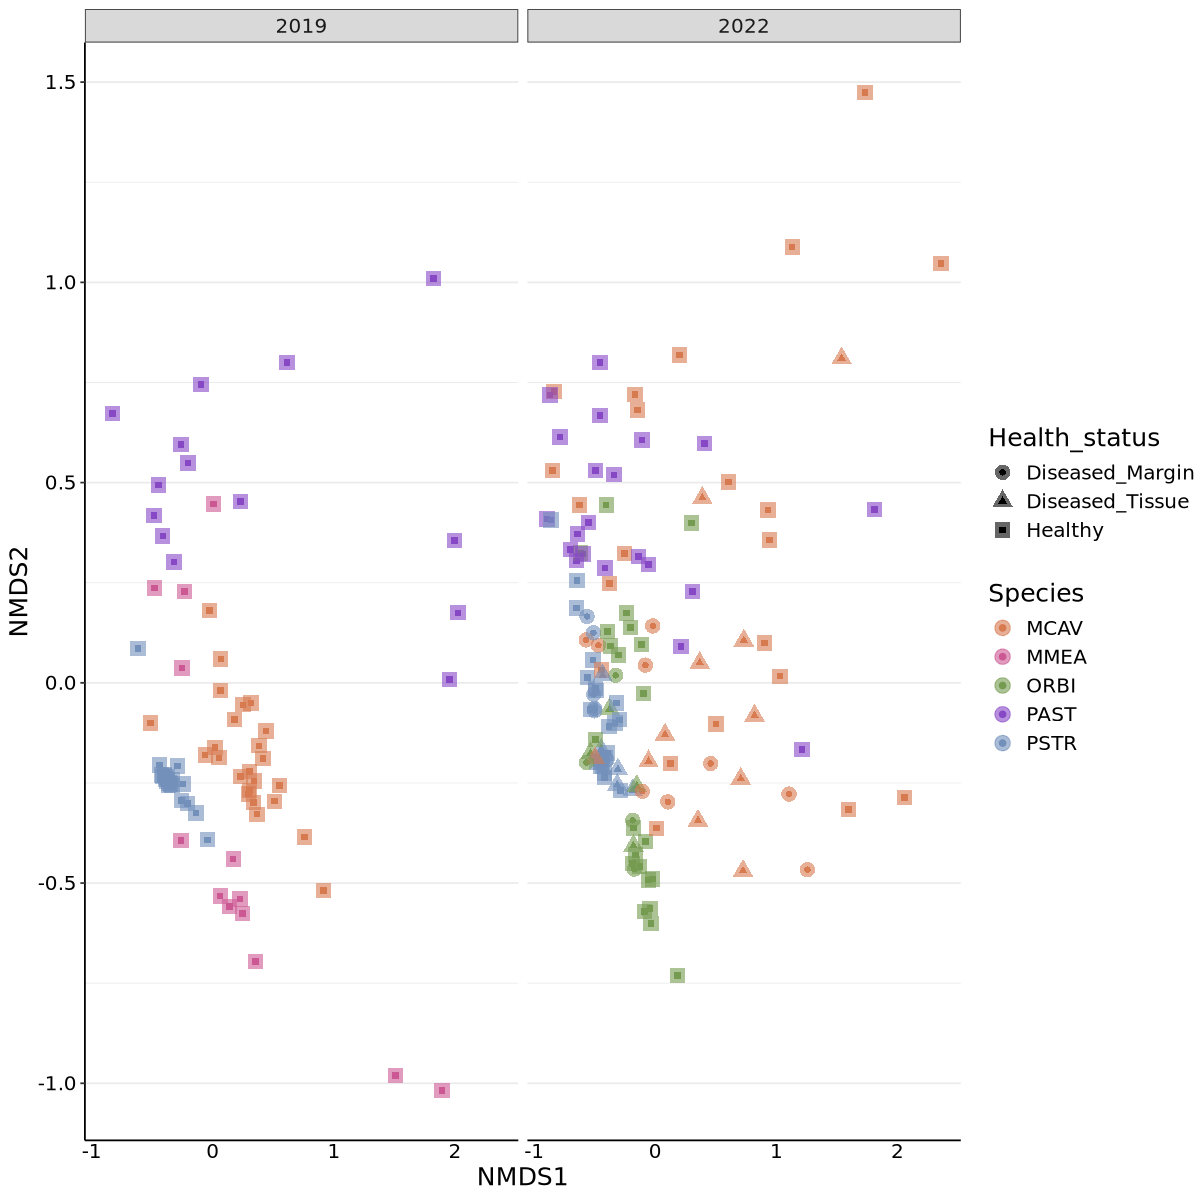

In [77]:
# facet by year
sctld_raw_plot <- plot_ordination(sctld_raw2, sctld_raw2.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_raw_plot

# all samples - separated by 2019 and 2022

In [78]:
# outliers really causing issues - see previous commits to view 
# leaving filtered out for now??

In [79]:
# 2019 only - RS
RS_ps <- subset_samples(sctld_raw2, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.113948 
Run 1 stress 0.1268532 
Run 2 stress 0.131261 
Run 3 stress 0.1131592 
... New best solution
... Procrustes: rmse 0.03244194  max resid 0.09310089 
Run 4 stress 0.1131593 
... Procrustes: rmse 0.0001337116  max resid 0.0006379558 
... Similar to previous best
Run 5 stress 0.1324046 
Run 6 stress 0.1319911 
Run 7 stress 0.1131592 
... Procrustes: rmse 3.079471e-05  max resid 0.0001502557 
... Similar to previous best
Run 8 stress 0.1348872 
Run 9 stress 0.124108 
Run 10 stress 0.1203835 
Run 11 stress 0.1112135 
... New best solution
... Procrustes: rmse 0.01285019  max resid 0.0981085 
Run 12 stress 0.1156699 
Run 13 stress 0.1148918 
Run 14 stress 0.1250919 
Run 15 stress 0.11944 
Run 16 stress 0.1156698 
Run 17 stress 0.1318733 
Run 18 stress 0.1351315 
Run 19 stress 0.1173185 
Run 20 stress 0.1358382 
Run 21 stress 0.111199 
... New best solution
... Procrustes: rmse 0.0006879477  max resid 0.00420687

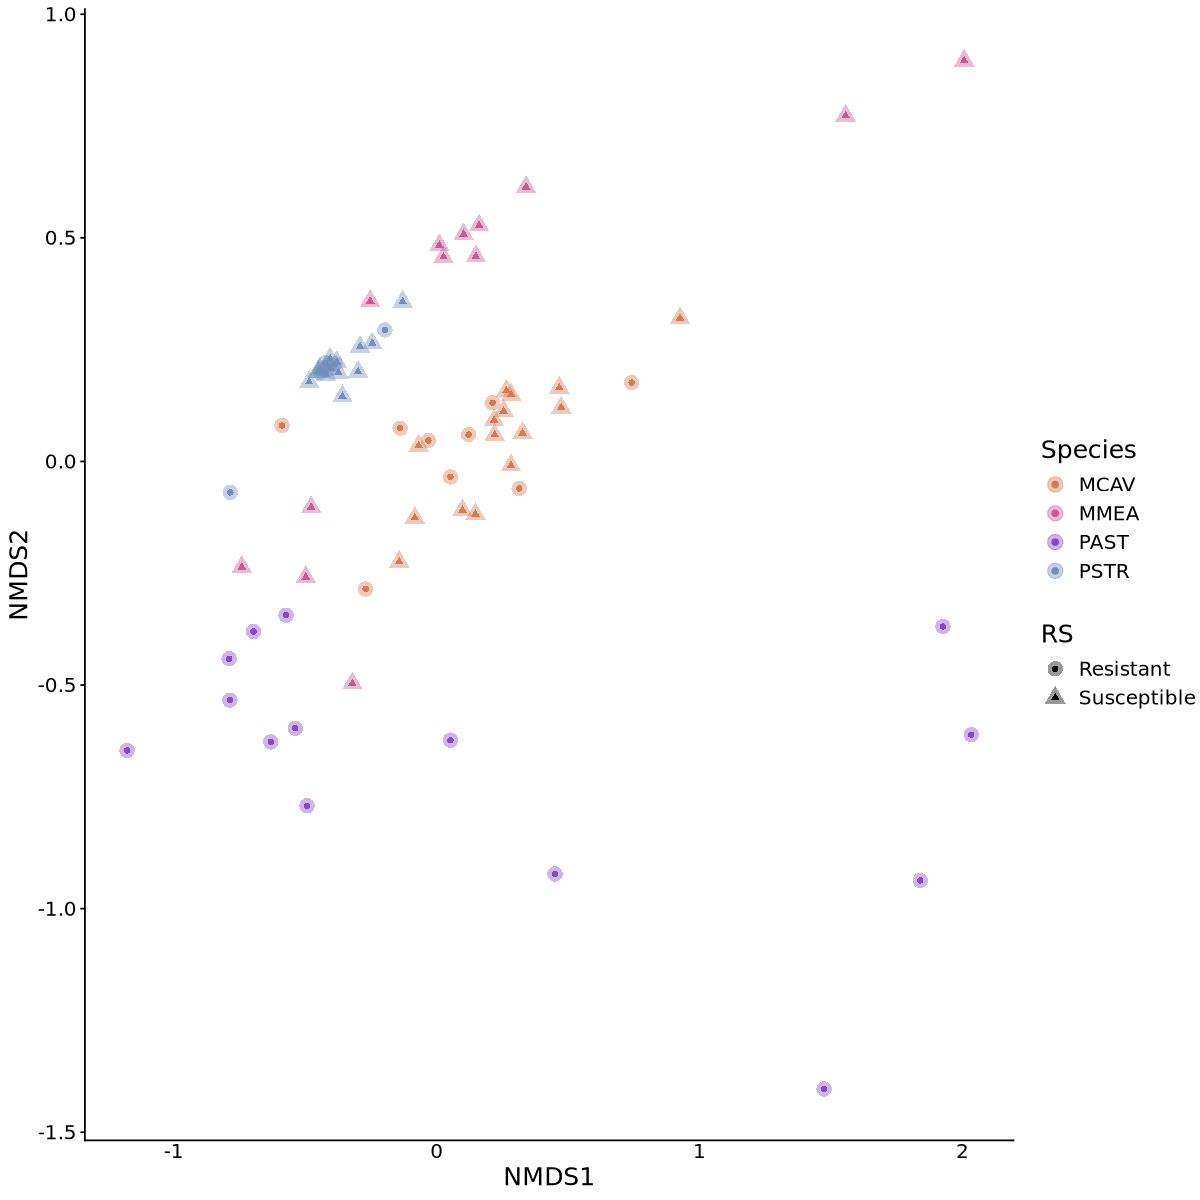

In [80]:
nmds_2019<-plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.4) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
# facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_classic()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
nmds_2019


# 2019 only 

In [81]:
ggsave(filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/plots/RS_2019_nmds.png", plot = nmds_2019, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [82]:
RS.ord
# Stress: 0.11


Call:
metaMDS(comm = veganifyOTU(physeq), distance = distance, trymax = 1000) 

global Multidimensional Scaling using monoMDS

Data:     wisconsin(sqrt(veganifyOTU(physeq))) 
Distance: bray 

Dimensions: 2 
Stress:     0.111199 
Stress type 1, weak ties
Best solution was repeated 1 time in 21 tries
The best solution was from try 21 (random start)
Scaling: centring, PC rotation, halfchange scaling 
Species: expanded scores based on ‘wisconsin(sqrt(veganifyOTU(physeq)))’ 


Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


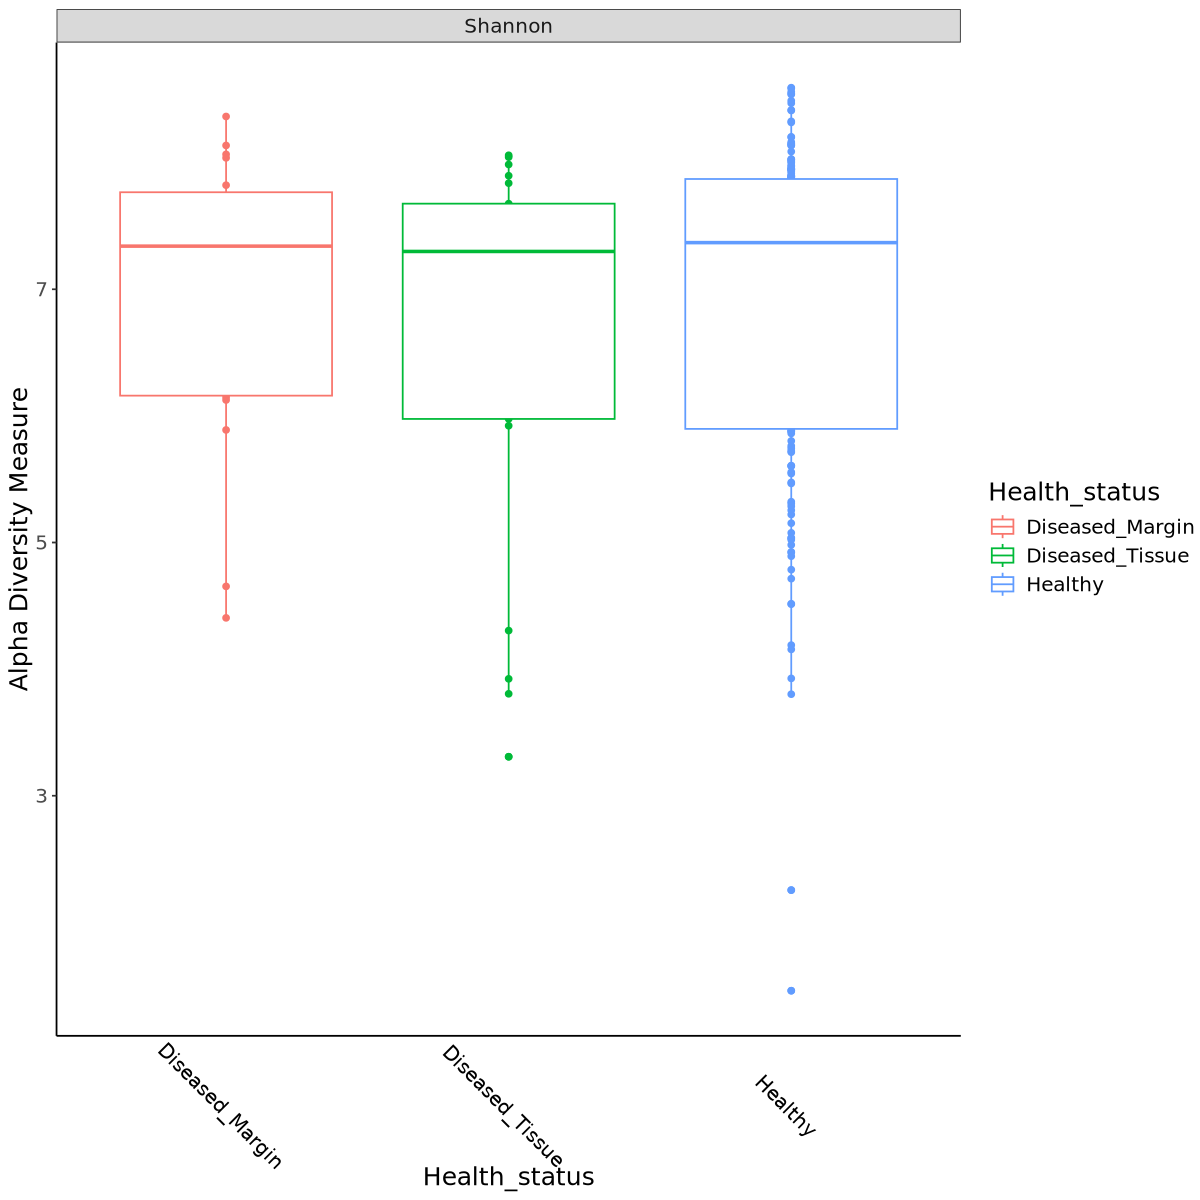

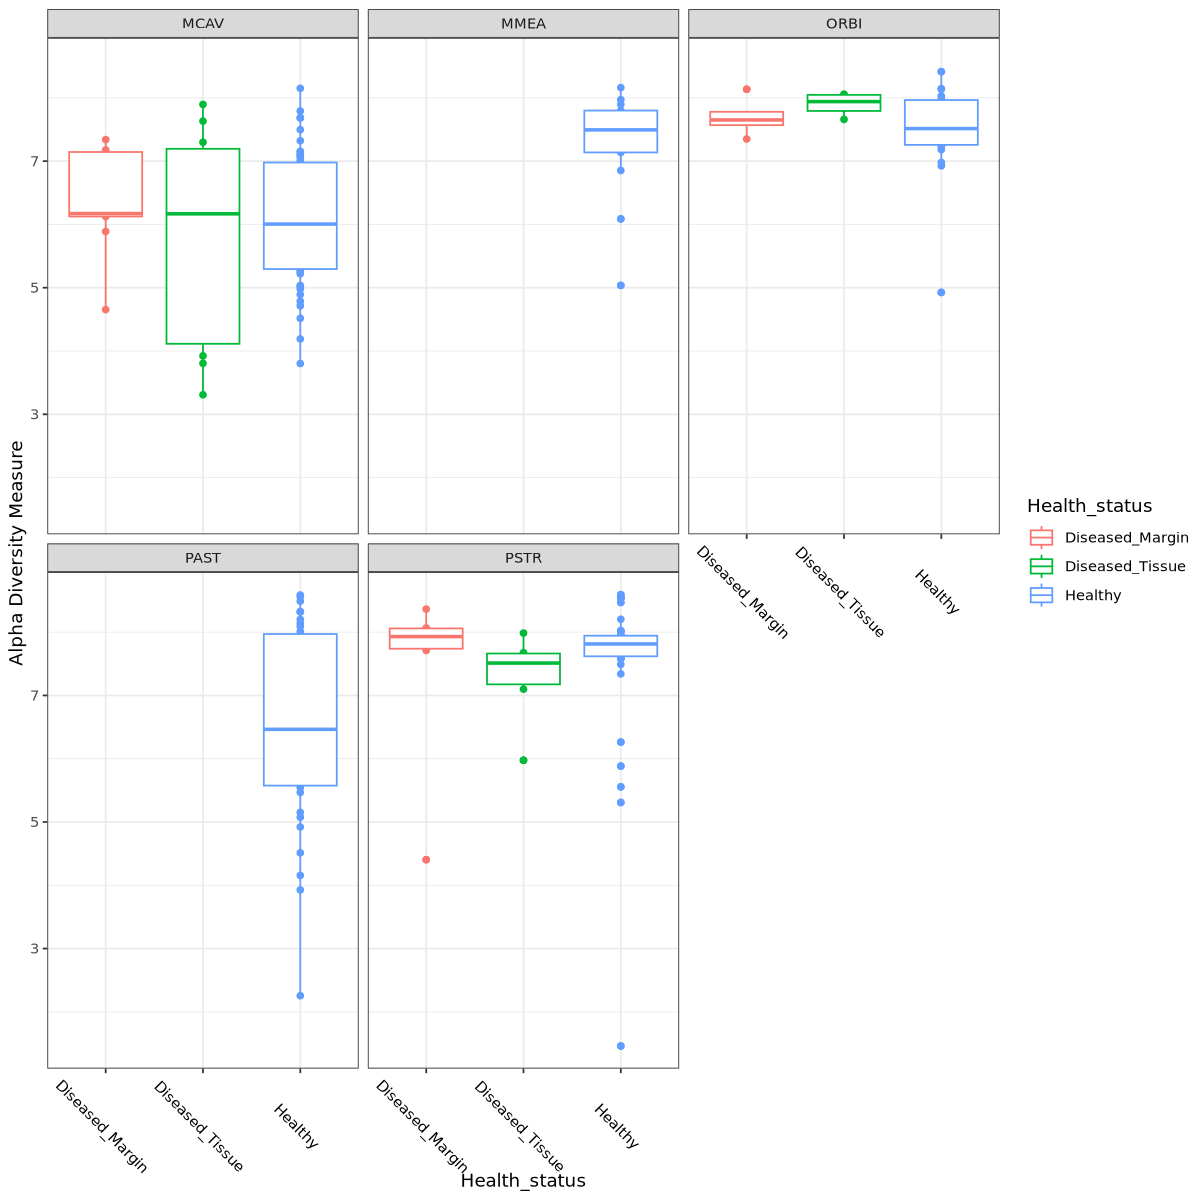

In [83]:
rich_status <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
    geom_boxplot() +
    # facet_wrap(~Species)+
    theme_bw()+
     theme(legend.position = "right",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_blank(),
        panel.grid.minor.y = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line = element_line(color = "black"),
        axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
        text = element_text(size = 15))
rich_status

plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

# all samples - spp x disease status

In [84]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


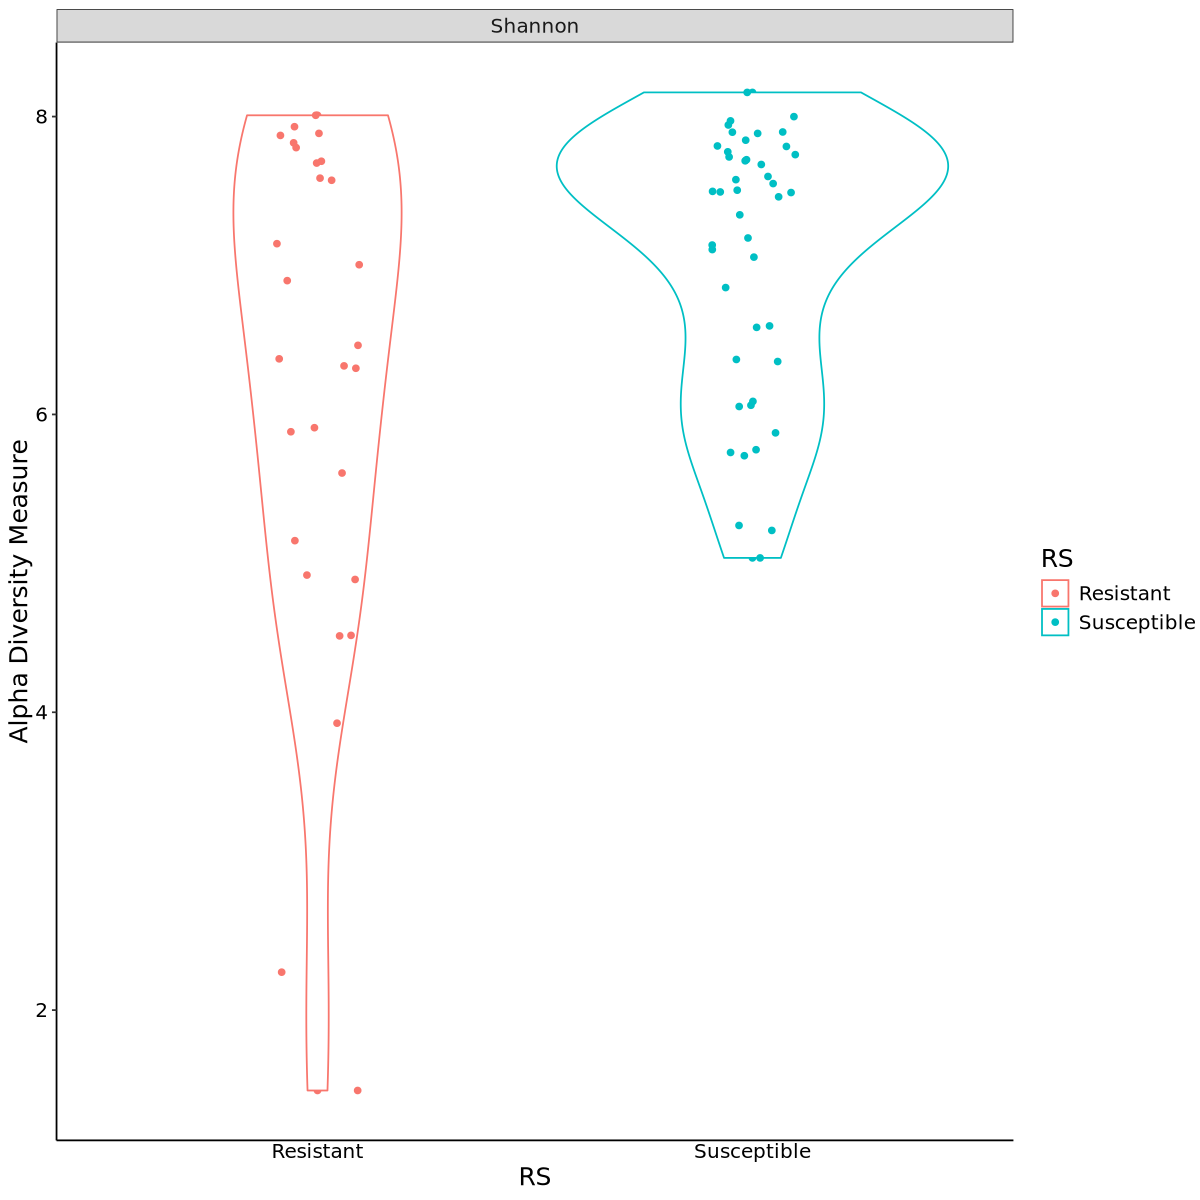

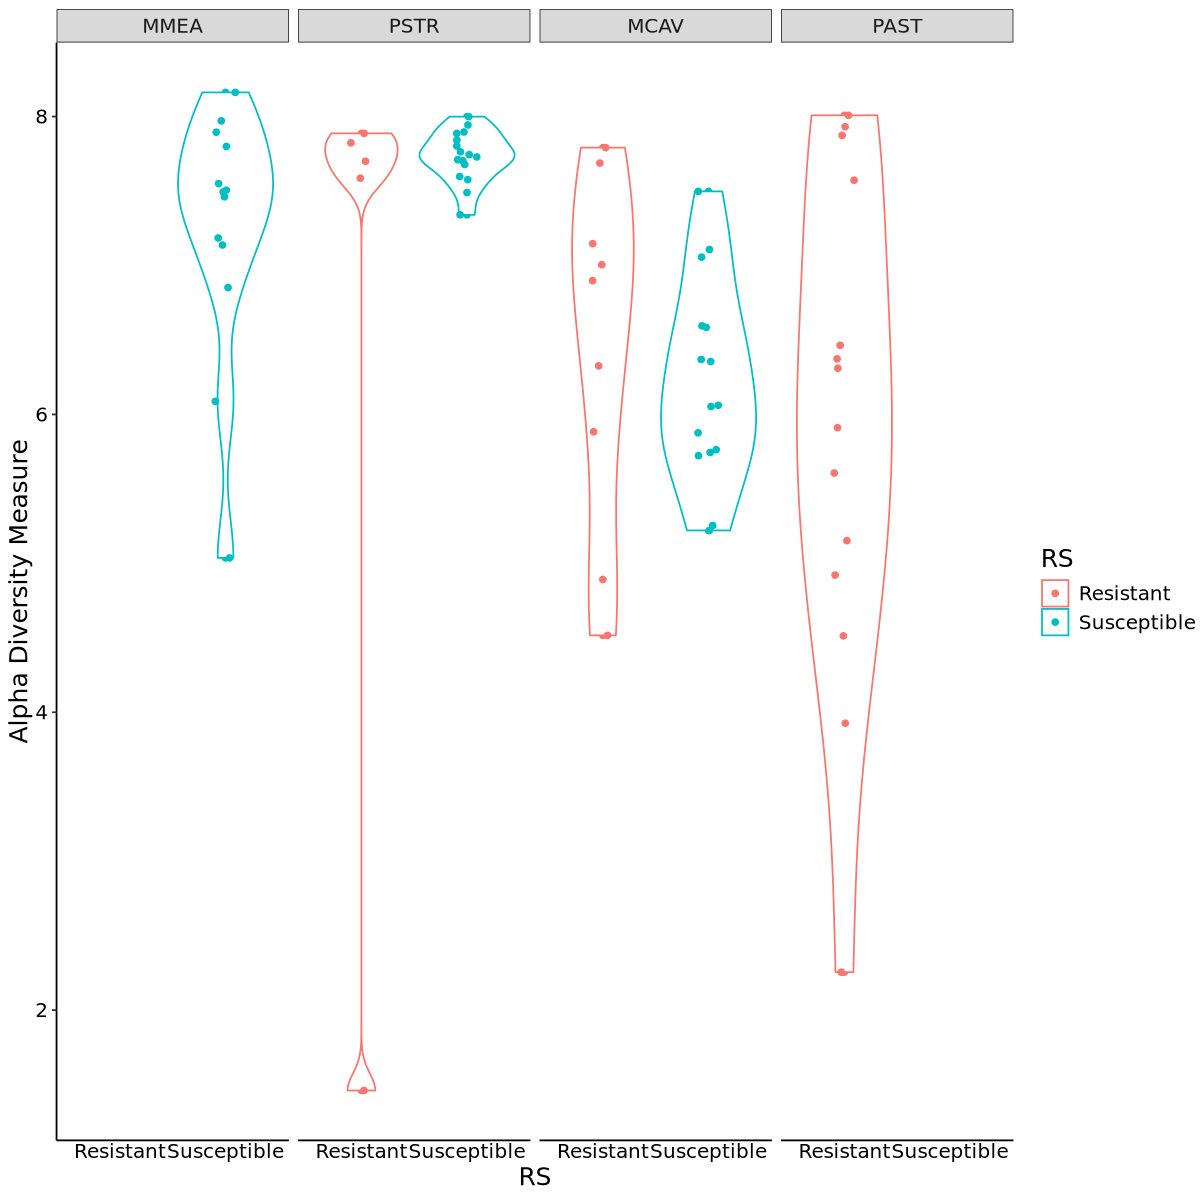

In [85]:
# order of species susceptibility 
# reorder colonies most -> least sus
spp_order<-c("MMEA",'PSTR','MCAV','PAST')
df_meta<-data.frame(sample_data(RS_ps))
sample_data(RS_ps)$Species <-
  factor(sample_data(RS_ps)$Species, levels = spp_order)

rich_status1 <- plot_richness(RS_ps, x="RS", color="RS", measures=c("Shannon")) + geom_violin() +
geom_jitter(height = 0, width = 0.1)+
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_grid(~Species)

# R vs S - 2019 only 

In [86]:
# most susceptible species are more diverse

In [87]:
options(repr.plot.width=15, repr.plot.height=10)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


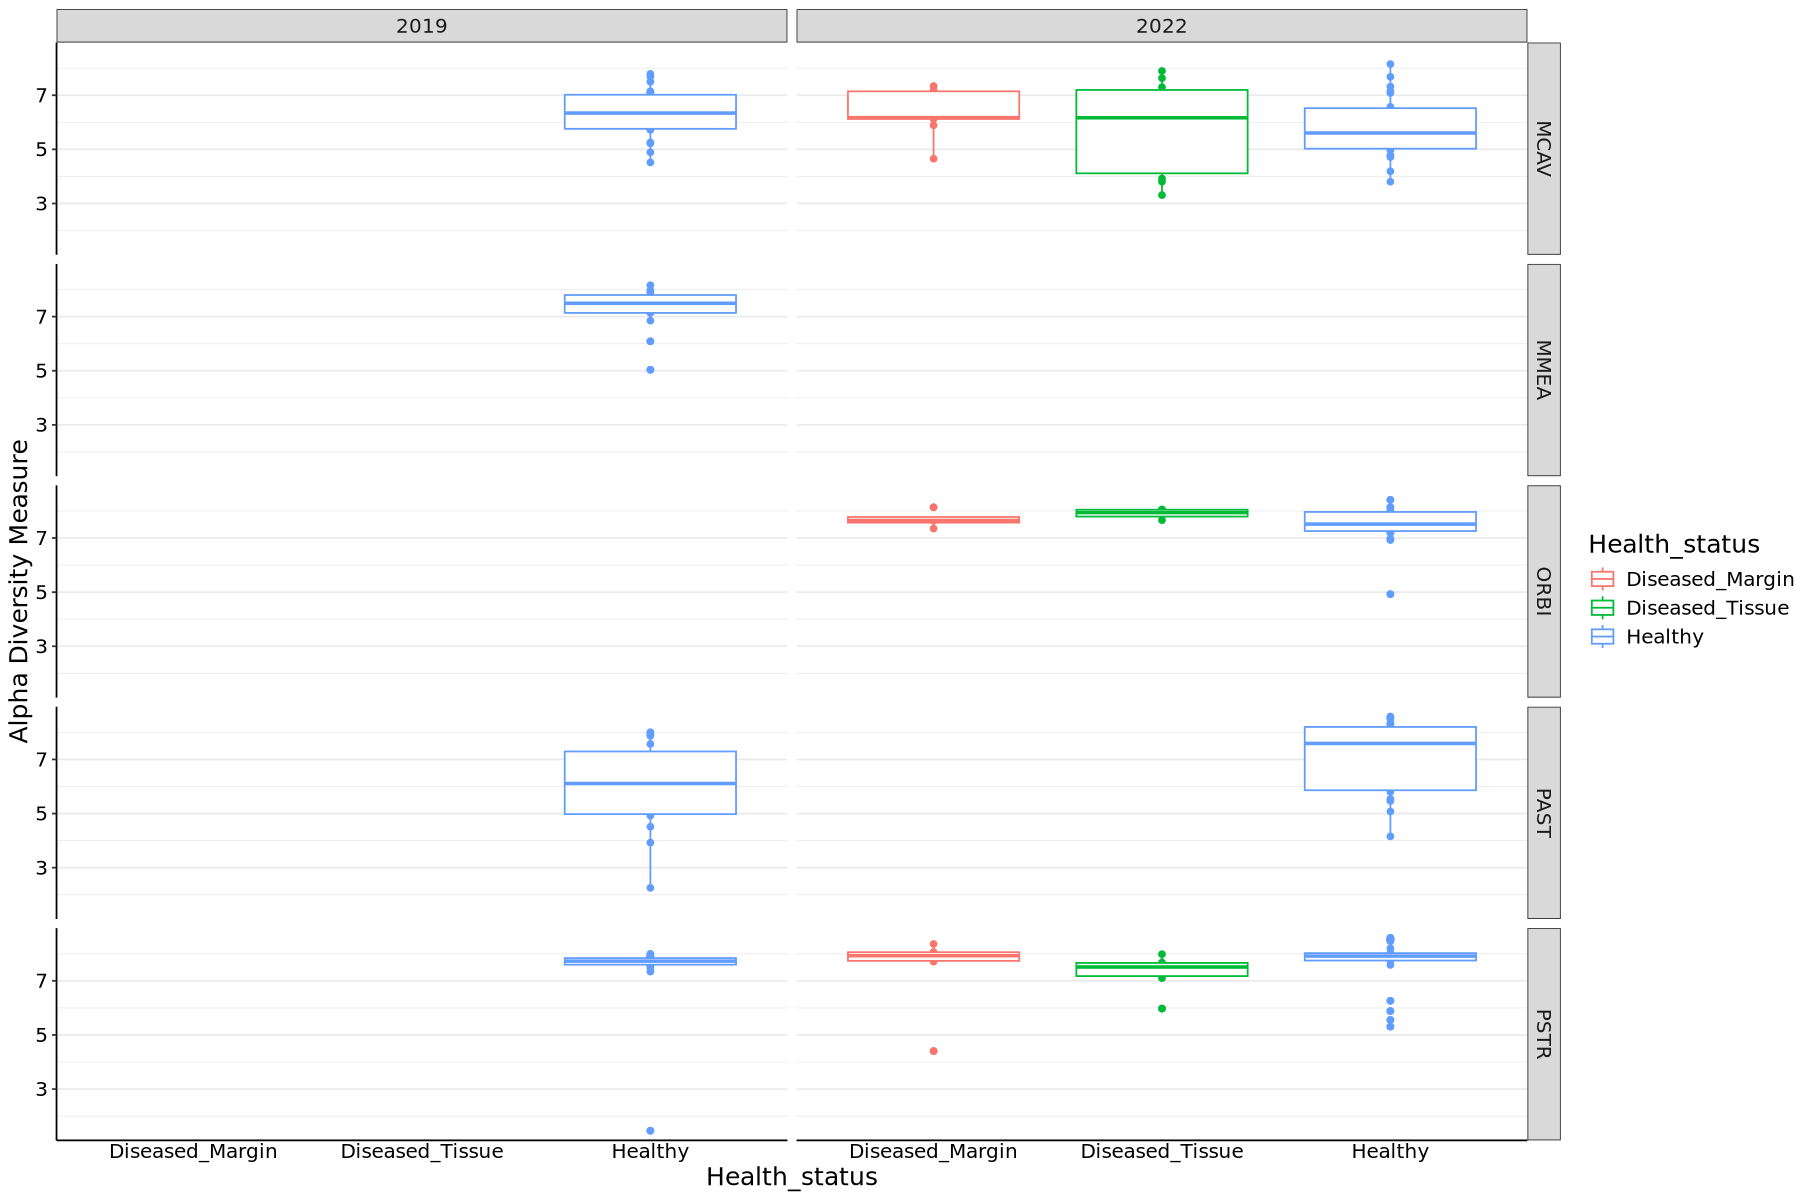

In [88]:
rich_species <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

rich_species+
    facet_grid(Species~year)

# all samples - year x spp x health status

In [89]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(sctld_raw2, method = "bray")
metadata2 <- as(phyloseq::sample_data(sctld_raw2), "data.frame")

In [90]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)
# all samples

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2       F Pr(>F)    
RS                1    1.499 0.02798  7.5578  0.001 ***
Species           4   12.369 0.23082 15.5897  0.001 ***
year              1    1.330 0.02483  6.7078  0.001 ***
RS:Species        2    0.365 0.00681  0.9205  0.553    
RS:year           1    0.166 0.00309  0.8344  0.548    
Species:year      2    0.905 0.01689  2.2817  0.002 ** 
RS:Species:year   1    0.257 0.00480  1.2956  0.212    
Residual        185   36.694 0.68478                   
Total           197   53.586 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [91]:
# Specie explains 28% variation
# RS only 2% but is significant
# year also only 2% but is significant
# Species * year is significant factor - variation between years depending on the species

In [92]:
permanova2 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
                       Df SumOfSqs      R2       F Pr(>F)    
Health_status           2    0.815 0.01522  2.0713  0.009 ** 
RS                      1    1.687 0.03148  8.5697  0.001 ***
Species                 4   12.268 0.22894 15.5825  0.001 ***
year                    1    1.002 0.01870  5.0901  0.001 ***
Health_status:Species   4    0.711 0.01327  0.9030  0.635    
RS:Species              2    0.363 0.00677  0.9221  0.559    
RS:year                 1    0.218 0.00408  1.1100  0.321    
Species:year            2    0.908 0.01694  2.3059  0.004 ** 
RS:Species:year         1    0.382 0.00713  1.9399  0.028 *  
Residual              179   35.232 0.65748                   
Total                 197   53.586 1.00000                   
---
Sign

In [93]:
# ok good adding health status shows similar results 
# health status is also significant effect (1.5% variation) 

In [94]:
permanova3 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.815 0.01522  2.1109  0.008 ** 
RS                               1    1.687 0.03148  8.7334  0.001 ***
Species                          4   12.268 0.22894 15.8801  0.001 ***
year                             1    1.002 0.01870  5.1873  0.001 ***
Transect                         3    1.164 0.02172  2.0086  0.002 ** 
Health_status:Species            4    0.677 0.01263  0.8762  0.709    
RS:Species                       2    0.357 0.00665  0.9230  0.547    
RS:year                          1    0.164 0.00306  0.8484  0.581    
Species:year                     2    0.892 0.01664  2.3089  0.007 ** 
Health_status:Transect         

In [95]:
# location is more important than health status?

In [96]:
# look at 2022 subset - how much does health status vary
dis_ps<- subset_samples(sctld_raw2, year == '2022')
bray_dist <- phyloseq::distance(dis_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(dis_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    1.013 0.02919  2.4264  0.001 ***
Species                          3    7.866 0.22665 12.5600  0.001 ***
Transect                         3    1.373 0.03956  2.1921  0.005 ** 
Health_status:Species            4    0.690 0.01987  0.8258  0.784    
Health_status:Transect           6    1.308 0.03769  1.0444  0.371    
Species:Transect                 8    2.299 0.06623  1.3764  0.025 *  
Health_status:Species:Transect   6    0.743 0.02142  0.5935  0.995    
Residual                        93   19.415 0.55940                   
Total                          125   34.707 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 

In [97]:
# species is more important than health status - same as from prelim results

In [98]:
#mcav only
# look at 2022 subset - how much does health status vary
mcav_ps<- subset_samples(sctld_raw2, Species == "MCAV" & year == '2022')
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.7596 0.06914 1.5489  0.064 .
RS                      1   0.4257 0.03875 1.7363  0.062 .
Transect                3   1.0526 0.09581 1.4310  0.081 .
Health_status:Transect  4   1.1473 0.10443 1.1698  0.225  
Residual               31   7.6010 0.69187                
Total                  41  10.9862 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [99]:
orbi_ps<- subset_samples(sctld_raw2, Species == "ORBI")
bray_dist <- phyloseq::distance(orbi_ps, method = "bray")
orbi_meta <- as(phyloseq::sample_data(orbi_ps), "data.frame")
orbi_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
print(orbi_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.3594 0.07663 1.1742  0.258  
RS                      1   0.1244 0.02652 0.8128  0.524  
Transect                3   0.8276 0.17644 1.8023  0.028 *
Health_status:Transect  4   0.4714 0.10050 0.7699  0.748  
RS:Transect             1   0.1525 0.03250 0.9960  0.415  
Residual               18   2.7551 0.58740                
Total                  29   4.6903 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [100]:
# maybe we do need to separate out orbi species...

In [101]:
# 2019 only 

In [102]:
bray_dist <- phyloseq::distance(RS_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(RS_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
                    Df SumOfSqs      R2       F Pr(>F)    
RS                   1   0.9197 0.05292  5.7062  0.002 ** 
Species              3   5.3624 0.30854 11.0906  0.001 ***
Transect             2   0.2303 0.01325  0.7145  0.823    
RS:Species           1   0.1714 0.00986  1.0633  0.347    
RS:Transect          2   0.3491 0.02009  1.0829  0.314    
Species:Transect     6   1.1151 0.06416  1.1532  0.224    
RS:Species:Transect  2   0.5287 0.03042  1.6402  0.046 *  
Residual            54   8.7032 0.50076                   
Total               71  17.3798 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [103]:
# within species, how much does RS explain difference

In [104]:
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~  RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Transect, data = mcav_meta, permutations = 999)
            Df SumOfSqs      R2      F Pr(>F)
RS           1   0.1966 0.05437 1.2876  0.212
Transect     2   0.3047 0.08428 0.9981  0.386
RS:Transect  2   0.3663 0.10132 1.1998  0.252
Residual    18   2.7479 0.76002              
Total       23   3.6156 1.00000              


### DESeq2 R vs S 2019

In [105]:
# make phyloseq fxn
run_deseq <- function(phylo_obj, comparison, contrast1, contrast2){
    ds_formula <- as.formula(paste0("~ ", comparison))
    ps_ds = phyloseq_to_deseq2(phylo_obj, ds_formula)
    
    for_ds = DESeq(ps_ds, test="Wald", fitType="parametric")
    res = results(for_ds, cooksCutoff = FALSE, contrast=c(comparison, contrast1, contrast2))
    alpha = 0.00001
    sigtab_a = res[which(res$padj < alpha), ]
    sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(phylo_obj)[rownames(sigtab_a), ], "matrix"))
    return(sigtab_all)
    }

view_ds_res<-function(sigtab_all, comparison,contrast1, contrast2){
    sigtab_res <- sigtab_all %>%
        arrange(padj)%>%
    # add contrast cols
        mutate(!!sym(comparison):= if_else(log2FoldChange<0, contrast2,contrast1))
    return(sigtab_res)
    }

In [106]:
#run DESeq2 on 2019 R vs S across species
## ALL SPECIES TOGETHER

ds_all = phyloseq_to_deseq2(RS_ps, ~ RS)
ds_all = DESeq(ds_all, test="Wald", fitType="parametric")
res = results(ds_all, cooksCutoff = FALSE, contrast=c("RS", "Resistant", "Susceptible"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(RS_ps)[rownames(sigtab_a), ], "matrix"))
res
head(sigtab_all)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 3131 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): RS Resistant vs Susceptible 
Wald test p-value: RS Resistant vs Susceptible 
DataFrame with 15885 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue        padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
2057741 50260.266        2.43406  0.616370   3.94902 7.84714e-05 0.002202432
1929291   479.204        1.08795  0.611382   1.77949 7.51599e-02 0.157626105
172371     26.258        3.10555  1.011936   3.06892 2.14833e-03 0.022685143
1325120  9354.296        2.76122  0.638821   4.32237 1.54363e-05 0.000572682
3101350    88.803        1.41543  0.593529   2.38476 1.70901e-02 0.069618460
...           ...            ...       ...       ...         ...         ...
3048446         0             NA        NA        NA          NA          NA
3432130         0             NA        NA        NA          NA          NA
2843718         0             NA        NA        NA          NA          NA
889953      

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,domain,kingdom,phylum,class,order,family,genus,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
3101277,187.2267,2.803622,0.4374466,6.409062,1.464172e-10,1.232833e-08,Bacteria,Bacillati,Actinomycetota,Acidimicrobiia,Acidimicrobiales,Candidatus_Poriferisodalaceae,Candidatus_Poriferisodalis,Candidatus Poriferisodalis sp.
3101276,318.8281,4.312102,0.6261258,6.886958,5.699810e-12,5.306852e-10,Bacteria,Bacillati,Actinomycetota,Acidimicrobiia,Acidimicrobiales,Candidatus_Hopanoidivoransaceae,Candidatus_Poriferisocius,Candidatus Poriferisocius sp.
28901,2404.5918,2.363544,0.3353958,7.047029,1.827779e-12,1.769839e-10,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Salmonella,Salmonella enterica
180282,1537.5973,2.362392,0.3751068,6.297919,3.016674e-10,2.496620e-08,Bacteria,Pseudomonadati,Pseudomonadota,Betaproteobacteria,Burkholderiales,Comamonadaceae,Delftia,Delftia tsuruhatensis
573,1507.1435,1.451967,0.2671685,5.434649,5.490431e-08,3.880573e-06,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Klebsiella,Klebsiella pneumoniae
1795815,684.0231,2.417405,0.3745155,6.454752,1.083963e-10,9.207029e-09,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Kitasatosporales,Streptomycetaceae,Streptomyces,Streptomyces sp. enrichment culture


In [107]:
# sort by most significant 
sorted_sigtab_all <- sigtab_all %>%
  arrange(padj)
head(sorted_sigtab_all)
dim(sorted_sigtab_all)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,domain,kingdom,phylum,class,order,family,genus,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2917715,26.788306,26.66391,1.588315,16.78755,3.010202e-63,2.914779e-59,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Marinobacteraceae,Marinobacter,Marinobacter sp. M3C
1980001,18.210861,26.12339,1.671028,15.63312,4.330534e-55,2.096628e-51,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Micrococcales,Promicromonosporaceae,Cellulosimicrobium,Cellulosimicrobium sp. TH-20
3066307,19.737069,25.94132,1.674431,15.49262,3.891140e-54,1.255930e-50,Bacteria,Bacillati,Mycoplasmatota,Mollicutes,Entomoplasmatales,Spiroplasmataceae,Spiroplasma,Spiroplasma endosymbiont of Apeira syringaria
2907545,9.663506,25.12383,1.648418,15.24117,1.884582e-52,4.562101e-49,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Kitasatosporales,Streptomycetaceae,Streptomyces,Streptomyces sp. GQFP
3348344,15.800630,-22.76507,1.495807,-15.21926,2.634982e-52,5.102905e-49,Bacteria,Bacillati,Chloroflexota,Dehalococcoidia,Dehalococcoidales,Dehalococcoidaceae,Dehalococcoides,Dehalococcoides sp. THU4
3404047,11.245537,24.99873,1.653778,15.11614,1.267660e-51,2.045791e-48,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Kitasatosporales,Streptomycetaceae,Streptomyces,Streptomyces sp. E-08


[1] 150  14

In [108]:
# add R vs S col
sigdiff_otus<-sorted_sigtab_all %>%
    mutate(RS = if_else(log2FoldChange<0, "Susceptible","Resistant"))

In [109]:
# export sig diff taxa
# write.csv(sorted_sigtab_all, file=".csv")

In [110]:
options(repr.plot.width=15, repr.plot.height=15)

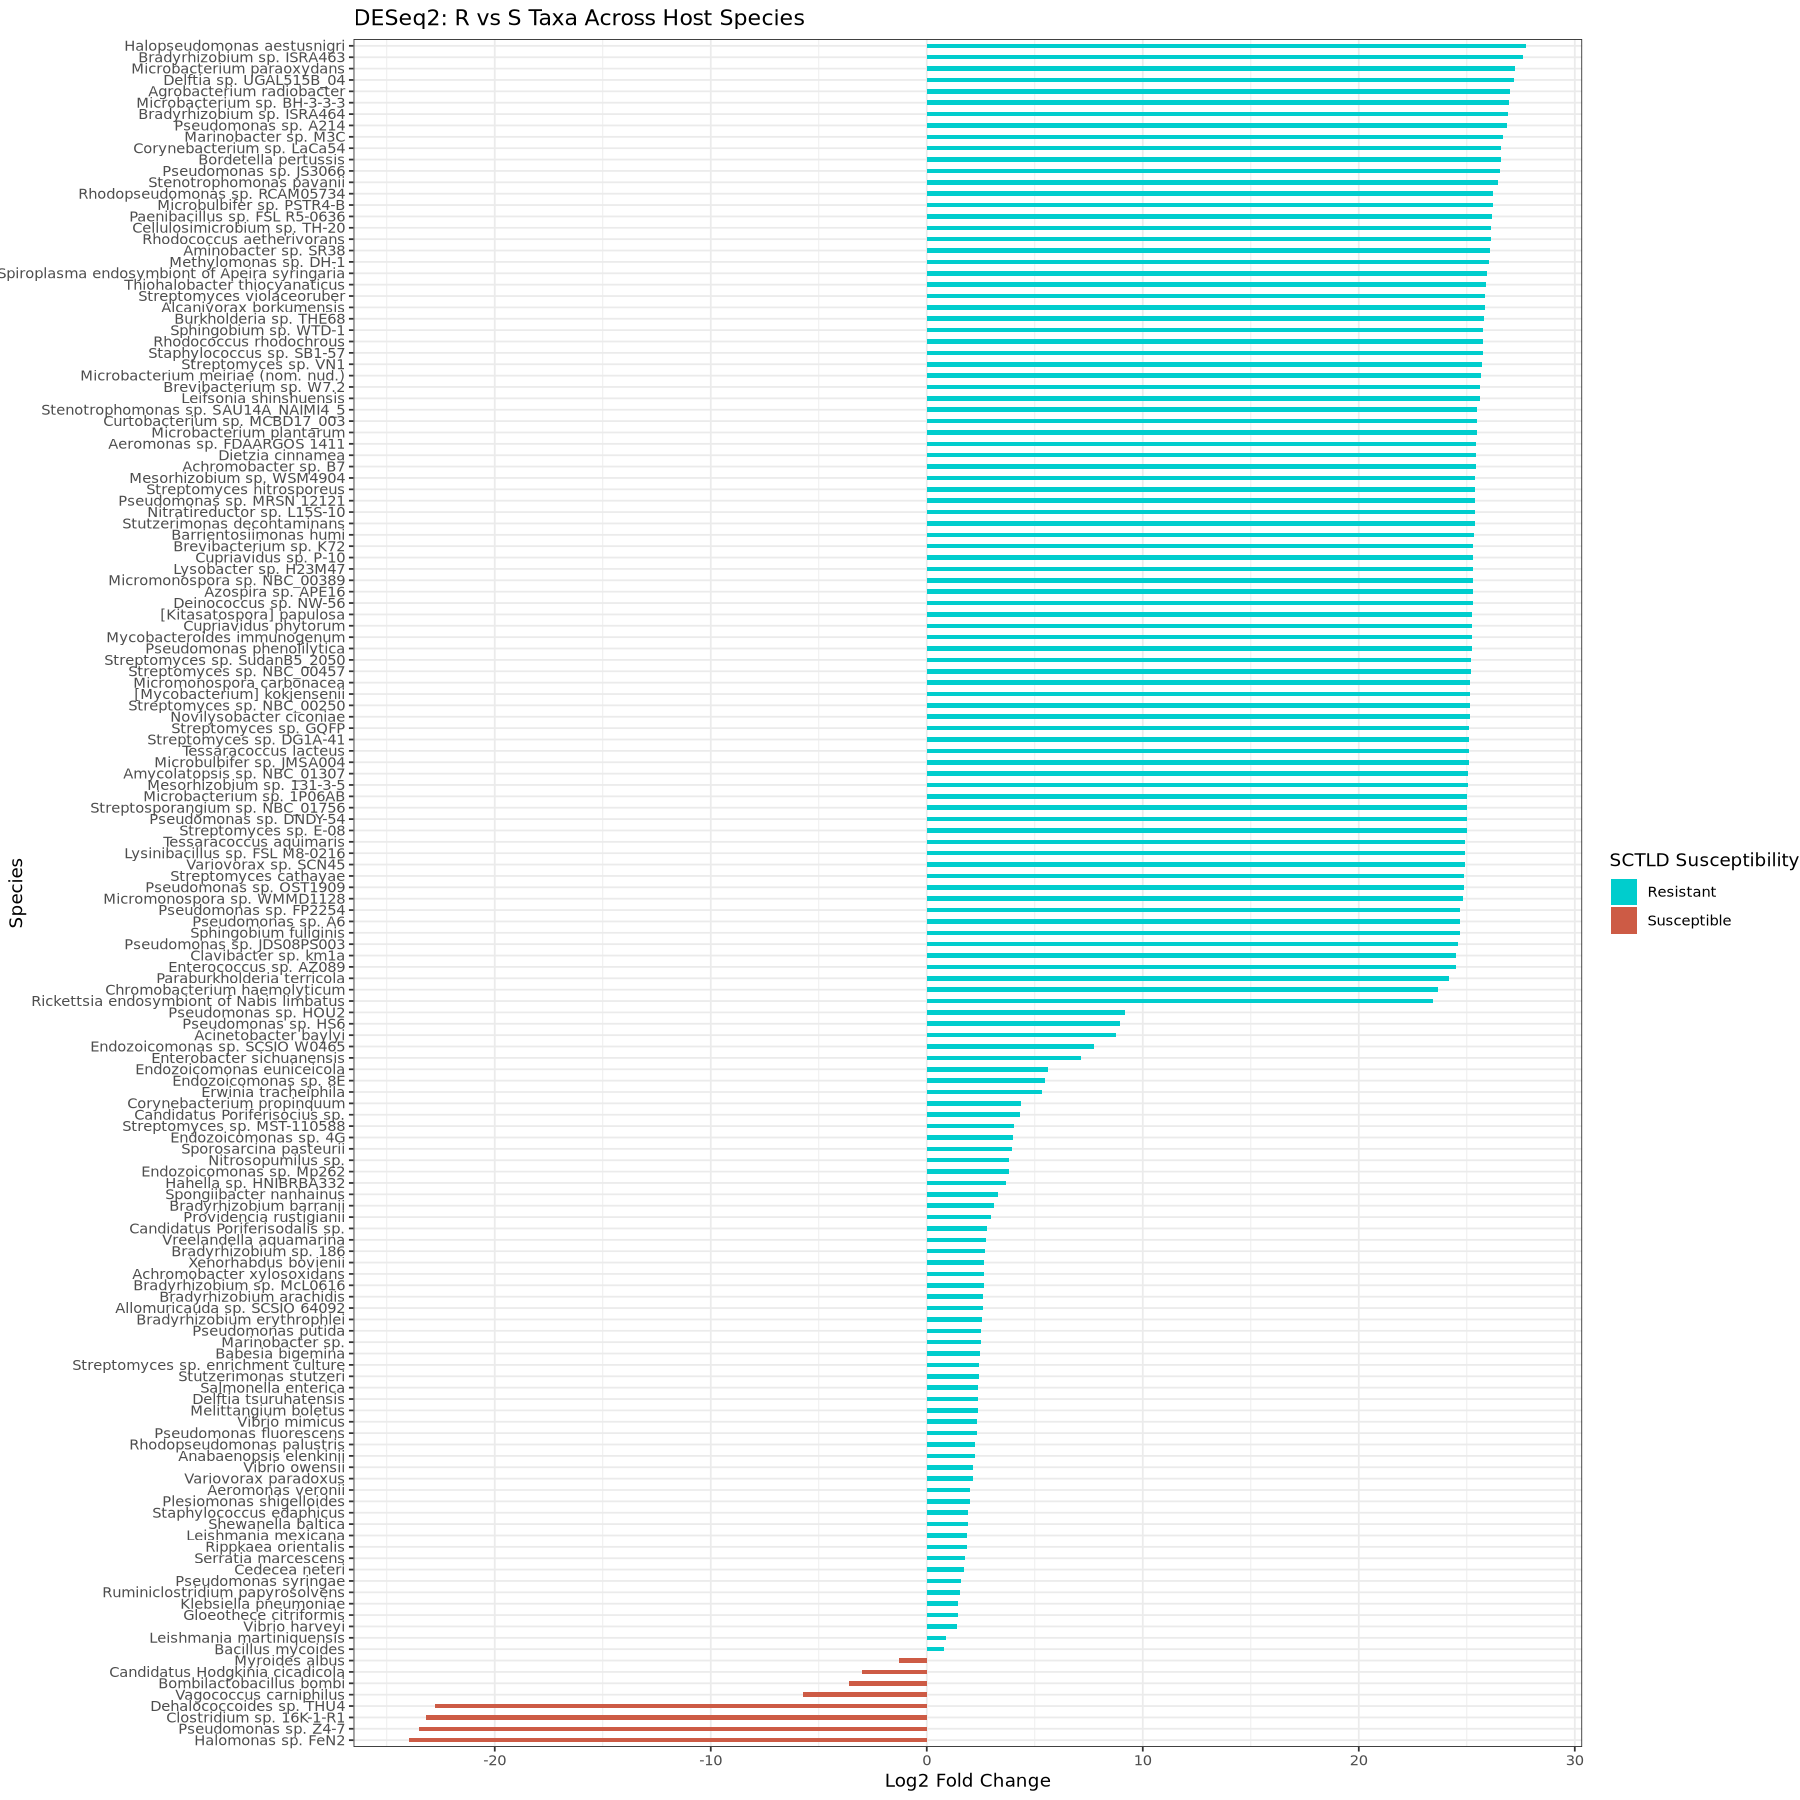

In [111]:
# plot significantly different OTUs 
ggplot(sigdiff_otus, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: R vs S Taxa Across Host Species", fill = "SCTLD Susceptibility")


In [112]:
# ggsave(filename = "DR_top_lfc_all_plot_HvDM_res.png", plot = top_lfc_all_plot, 
#       width = 10,
#       height = 15,
#       units = "in",
#       dpi = 300)

In [113]:
# try at genus level - all spp 
ps_genus<-tax_glom(sctld_raw, taxrank = "genus")
genus_ds<-run_deseq(ps_genus, "RS","Resistant","Susceptible")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1085 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [114]:
genus_res<-view_ds_res(genus_ds, "RS","Resistant","Susceptible")
genus_res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,domain,kingdom,phylum,class,order,family,genus,species,RS
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1155739,549.07861,3.642154,0.3062904,11.891176,1.315415e-32,3.616076e-29,Bacteria,Bacillati,Cyanobacteriota,Cyanophyceae,Coleofasciculales,Coleofasciculaceae,Moorena,NA,Resistant
1795815,23491.34565,2.227797,0.2237751,9.955520,2.385725e-23,2.186119e-20,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Kitasatosporales,Streptomycetaceae,Streptomyces,NA,Resistant
34073,2027.63453,2.555002,0.2558591,9.985975,1.755662e-23,2.186119e-20,Bacteria,Pseudomonadati,Pseudomonadota,Betaproteobacteria,Burkholderiales,Comamonadaceae,Variovorax,NA,Resistant
2918516,2366.28526,3.346752,0.3438185,9.734066,2.157914e-22,1.483026e-19,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Oceanospirillales,Endozoicomonadaceae,Endozoicomonas,NA,Resistant
68895,1997.96645,2.473036,0.2559854,9.660846,4.421983e-22,2.191795e-19,Bacteria,Pseudomonadati,Pseudomonadota,Betaproteobacteria,Burkholderiales,Burkholderiaceae,Cupriavidus,NA,Resistant
1572644,3163.78595,2.707846,0.2805248,9.652785,4.783837e-22,2.191795e-19,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Micrococcales,Microbacteriaceae,Microbacterium,NA,Resistant
37326,1666.20488,2.284128,0.2429362,9.402170,5.344910e-21,2.099023e-18,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Mycobacteriales,Nocardiaceae,Nocardia,NA,Resistant
520,947.99430,3.072198,0.3292076,9.332097,1.037962e-20,3.566698e-18,Bacteria,Pseudomonadati,Pseudomonadota,Betaproteobacteria,Burkholderiales,Alcaligenaceae,Bordetella,NA,Resistant
202950,5184.66048,1.319834,0.1425071,9.261533,2.015187e-20,6.155277e-18,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Moraxellales,Moraxellaceae,Acinetobacter,NA,Resistant


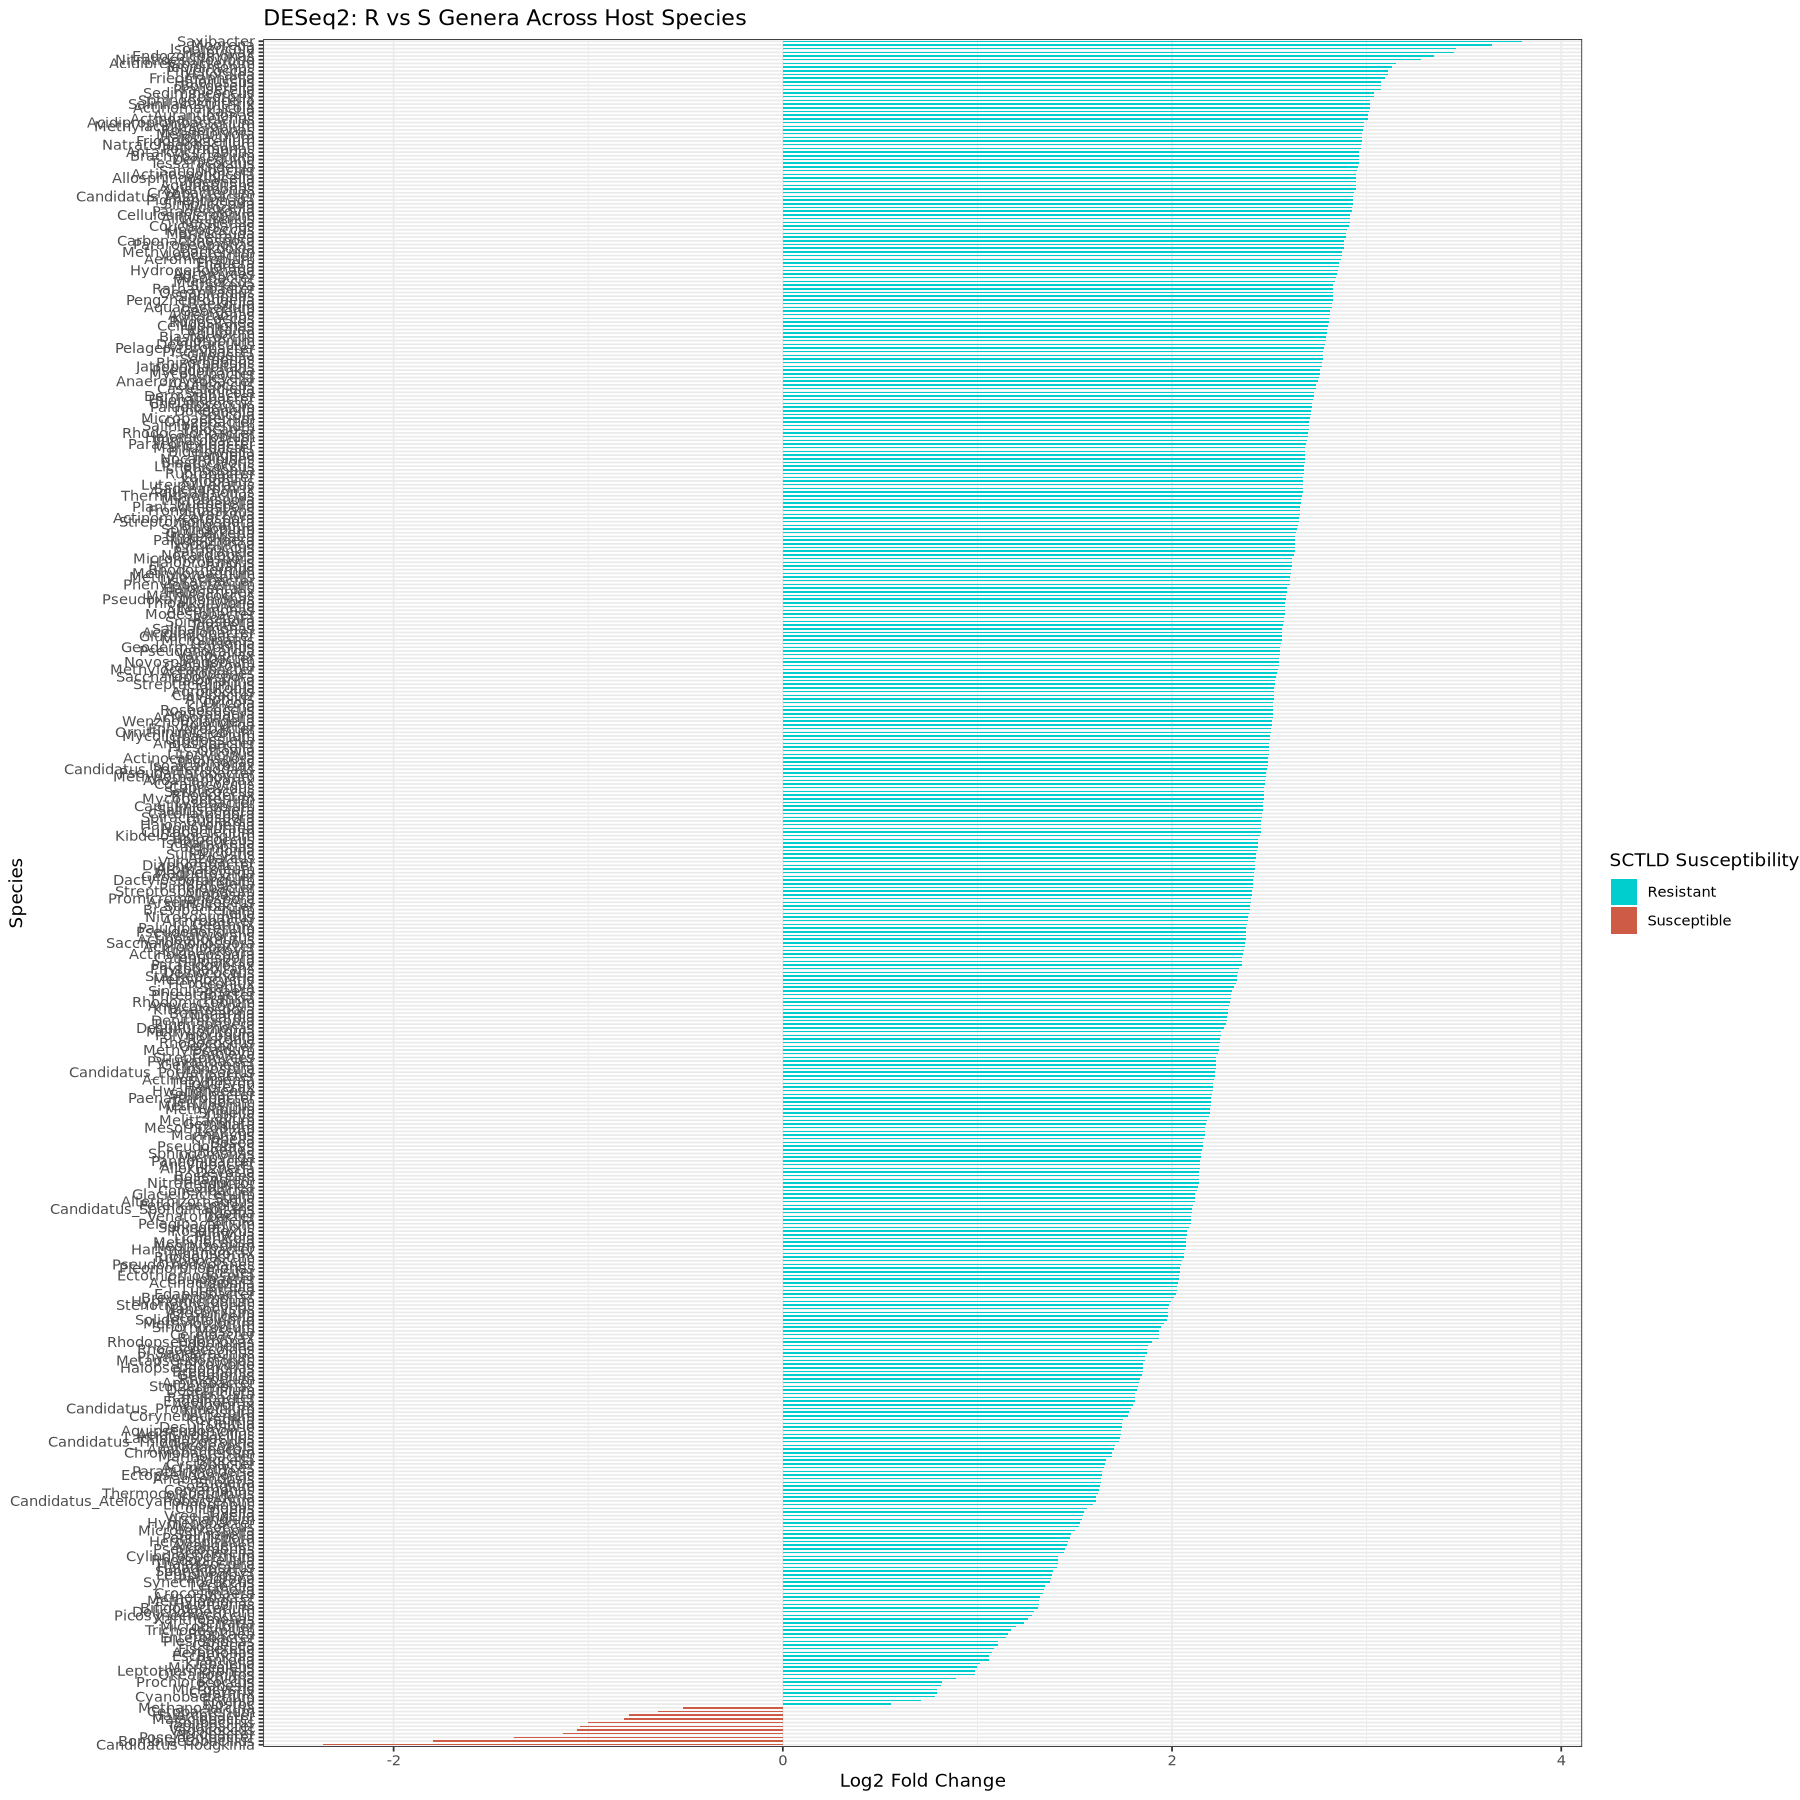

In [115]:
# plot significantly different OTUs - genus
ggplot(genus_res, aes(x = reorder(genus,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: R vs S Genera Across Host Species", fill = "SCTLD Susceptibility")

In [116]:
# family level - all spp 
ps_fam<-tax_glom(sctld_raw, taxrank = "family")
fam_ds<-run_deseq(ps_fam, "RS","Resistant","Susceptible")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 193 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



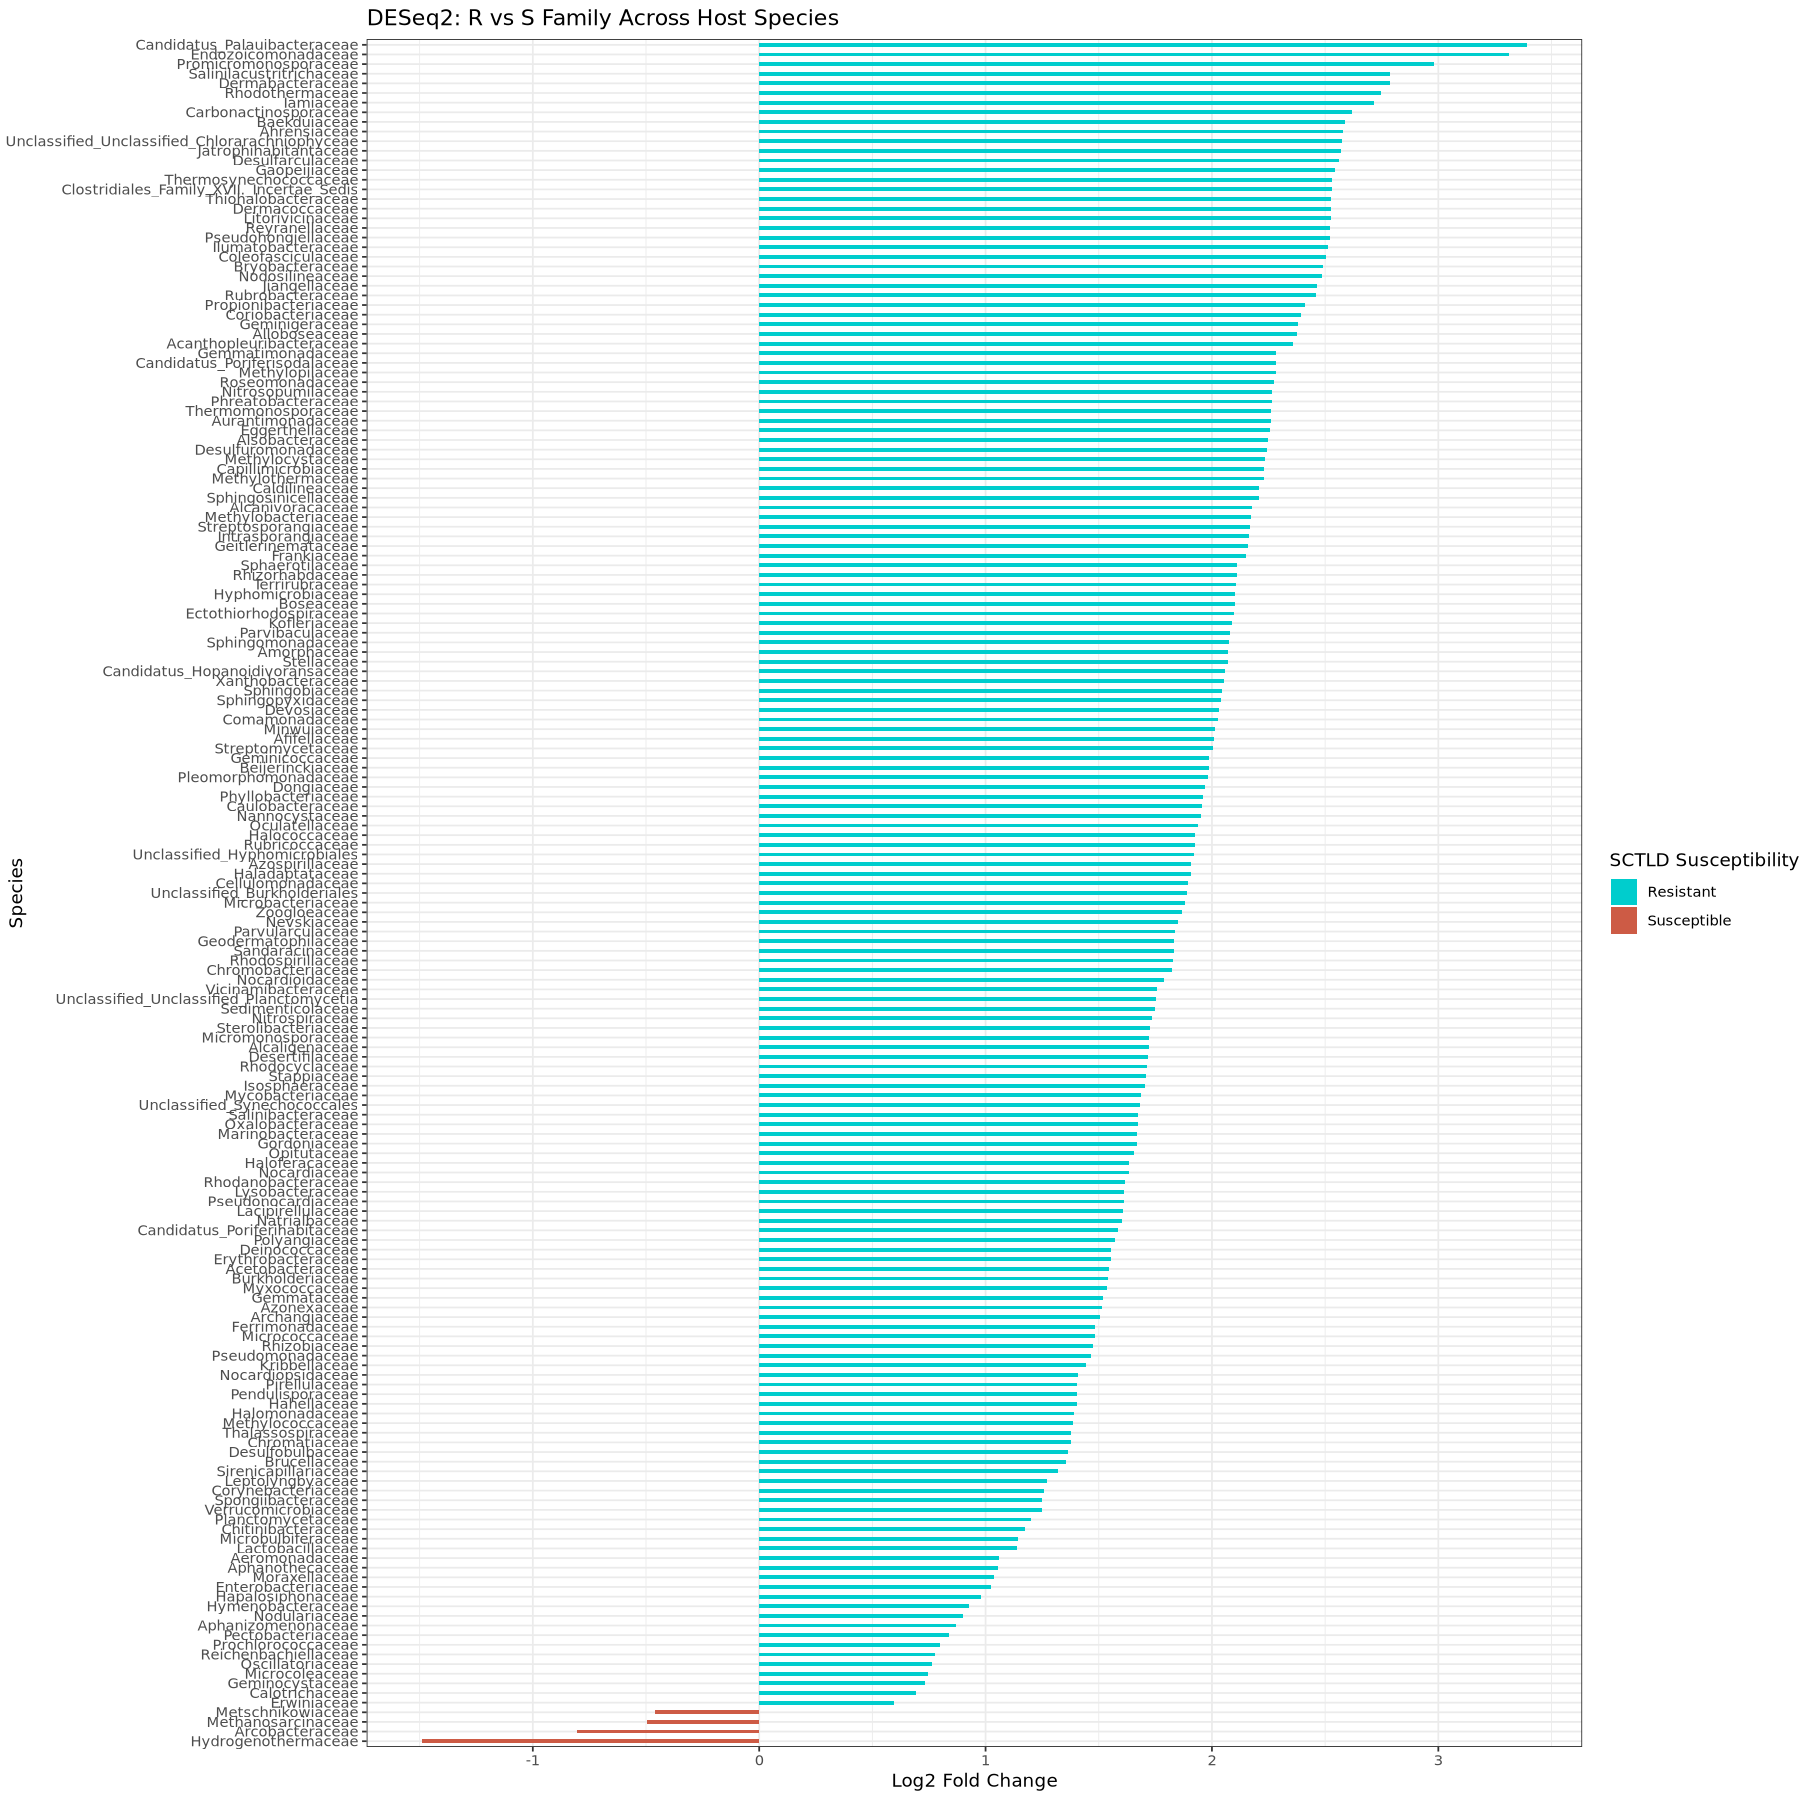

In [117]:
fam_res<-view_ds_res(fam_ds, "RS","Resistant","Susceptible")

ggplot(fam_res, aes(x = reorder(family,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: R vs S Family Across Host Species", fill = "SCTLD Susceptibility")

#### MCAV

In [118]:
#run DESeq2 on MCAV
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")

mcav_rs = phyloseq_to_deseq2(mcav_ps, ~ RS)
mcav_rs = DESeq(mcav_rs, test="Wald", fitType="parametric")
res = results(mcav_rs, cooksCutoff = FALSE, contrast=c("RS", "Resistant", "Susceptible"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab_a, "data.frame"), as(tax_table(mcav_ps)[rownames(sigtab_a), ], "matrix"))

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 4250 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [119]:
# sort by most significant 
sigtab_mcav <- sigtab_mcav %>%
  arrange(padj)%>%
# add R vs S col
    mutate(RS = if_else(log2FoldChange<0, "Susceptible","Resistant"))
head(sigtab_mcav)
dim(sigtab_mcav)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,domain,kingdom,phylum,class,order,family,genus,species,RS
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2986766,47.757042,25.53009,2.777448,9.191924,3.858772e-20,3.513026e-16,Bacteria,Pseudomonadati,Pseudomonadota,Betaproteobacteria,Burkholderiales,Comamonadaceae,Delftia,Delftia sp. UGAL515B_04,Resistant
2866199,13.190389,23.74540,3.027199,7.844016,4.363612e-15,1.986316e-11,Bacteria,Pseudomonadati,Pseudomonadota,Alphaproteobacteria,Hyphomicrobiales,Nitrobacteraceae,Bradyrhizobium,Bradyrhizobium sp. ISRA463,Resistant
2866282,7.356472,22.98450,3.028004,7.590642,3.183238e-14,9.660068e-11,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,Pseudomonas sp. PS1(2021),Resistant
3391428,5.960511,22.65977,3.028426,7.482358,7.300062e-14,1.248138e-10,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Mycobacteriales,Corynebacteriaceae,Corynebacterium,Corynebacterium sp. LaCa54,Resistant
3391431,5.673523,22.61306,3.028539,7.466656,8.225864e-14,1.248138e-10,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Mycobacteriales,Corynebacteriaceae,Corynebacterium,Corynebacterium sp. LaCa97,Resistant
1701090,6.301095,22.73610,3.028309,7.507853,6.010505e-14,1.248138e-10,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Mycobacteriales,Gordoniaceae,Gordonia,Gordonia hongkongensis,Resistant


[1]  7 15

In [120]:
options(repr.plot.height = 15, repr.plot.width = 15)

In [121]:
custom_list

PSTR      MCAV      PAST      ORBI      MMEA       NEG 
"#7290ba" "#d77a51" "#8748c6" "#759b50" "#cc5893" "#b05e3f"

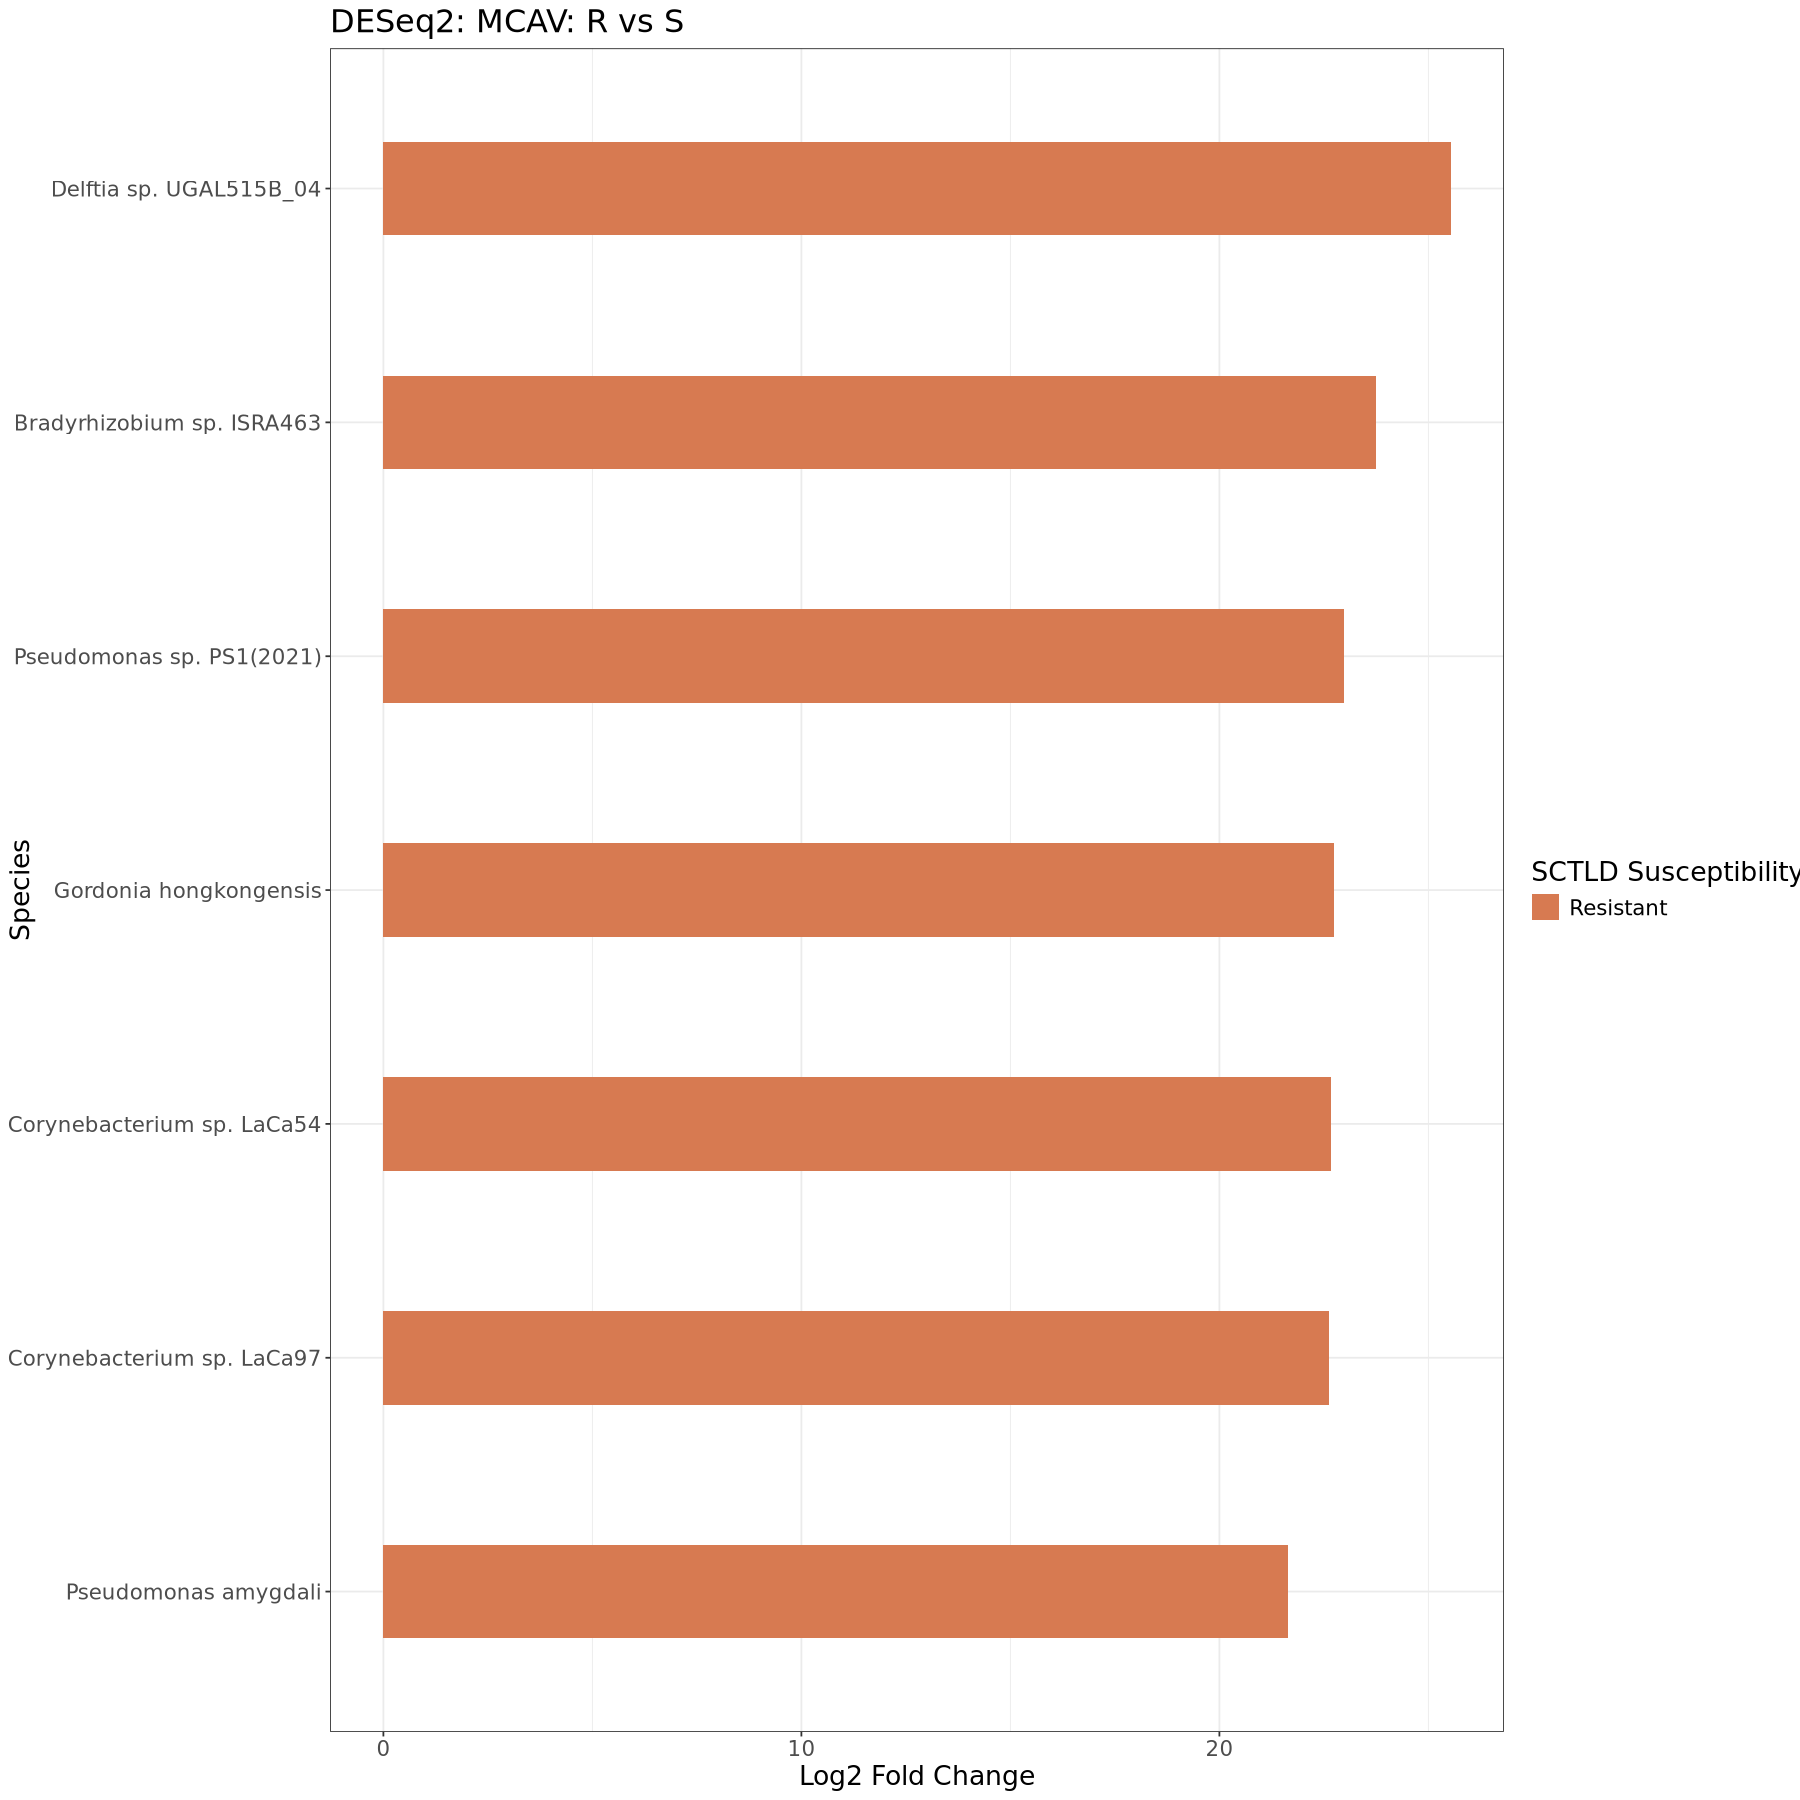

In [122]:
# plot significantly different OTUs 
ggplot(sigtab_mcav, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="#d77a51", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: MCAV: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 16)) 


In [123]:
# genus level
mcav_ps_genus<- subset_samples(ps_genus, Species == "MCAV")
genus_mcav_ds<-run_deseq(mcav_ps_genus, "RS","Resistant","Susceptible")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1247 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



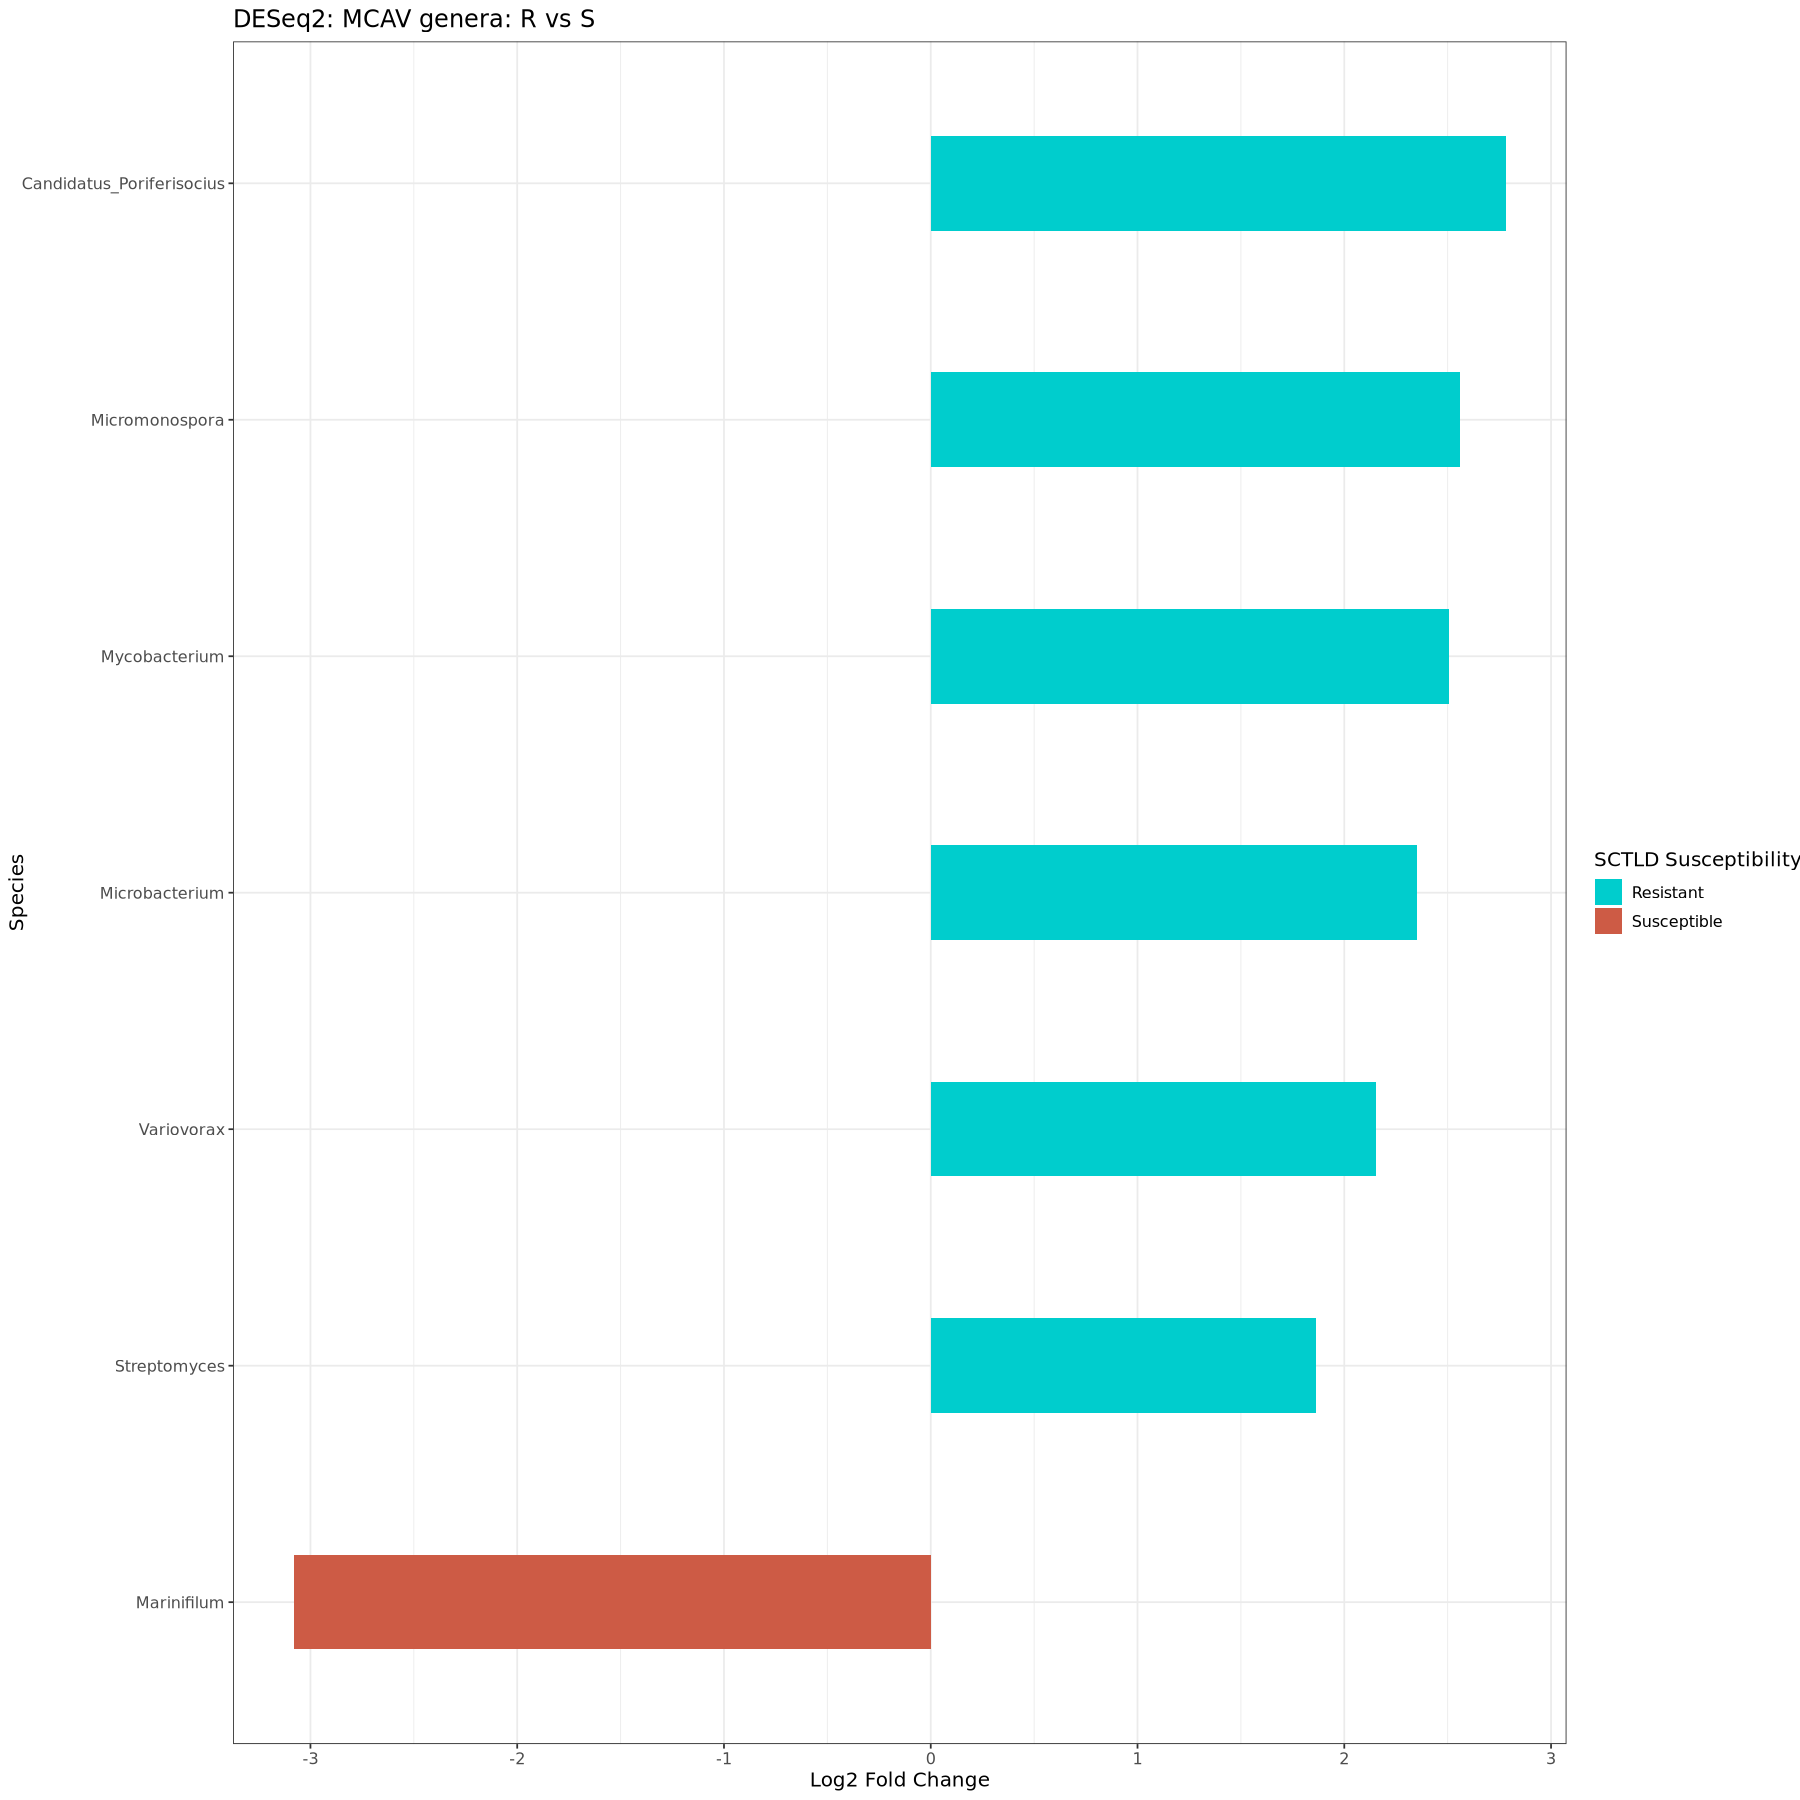

In [124]:
mcav_genus_res<-view_ds_res(genus_mcav_ds, "RS","Resistant","Susceptible")

# plot significantly different OTUs 
ggplot(mcav_genus_res, aes(x = reorder(genus,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: MCAV genera: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 12)) 

#### PSTR

In [125]:
pstr_ps<- subset_samples(RS_ps, Species == "PSTR")

pstr_ds<-run_deseq(pstr_ps, "RS","Resistant","Susceptible")

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 3136 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



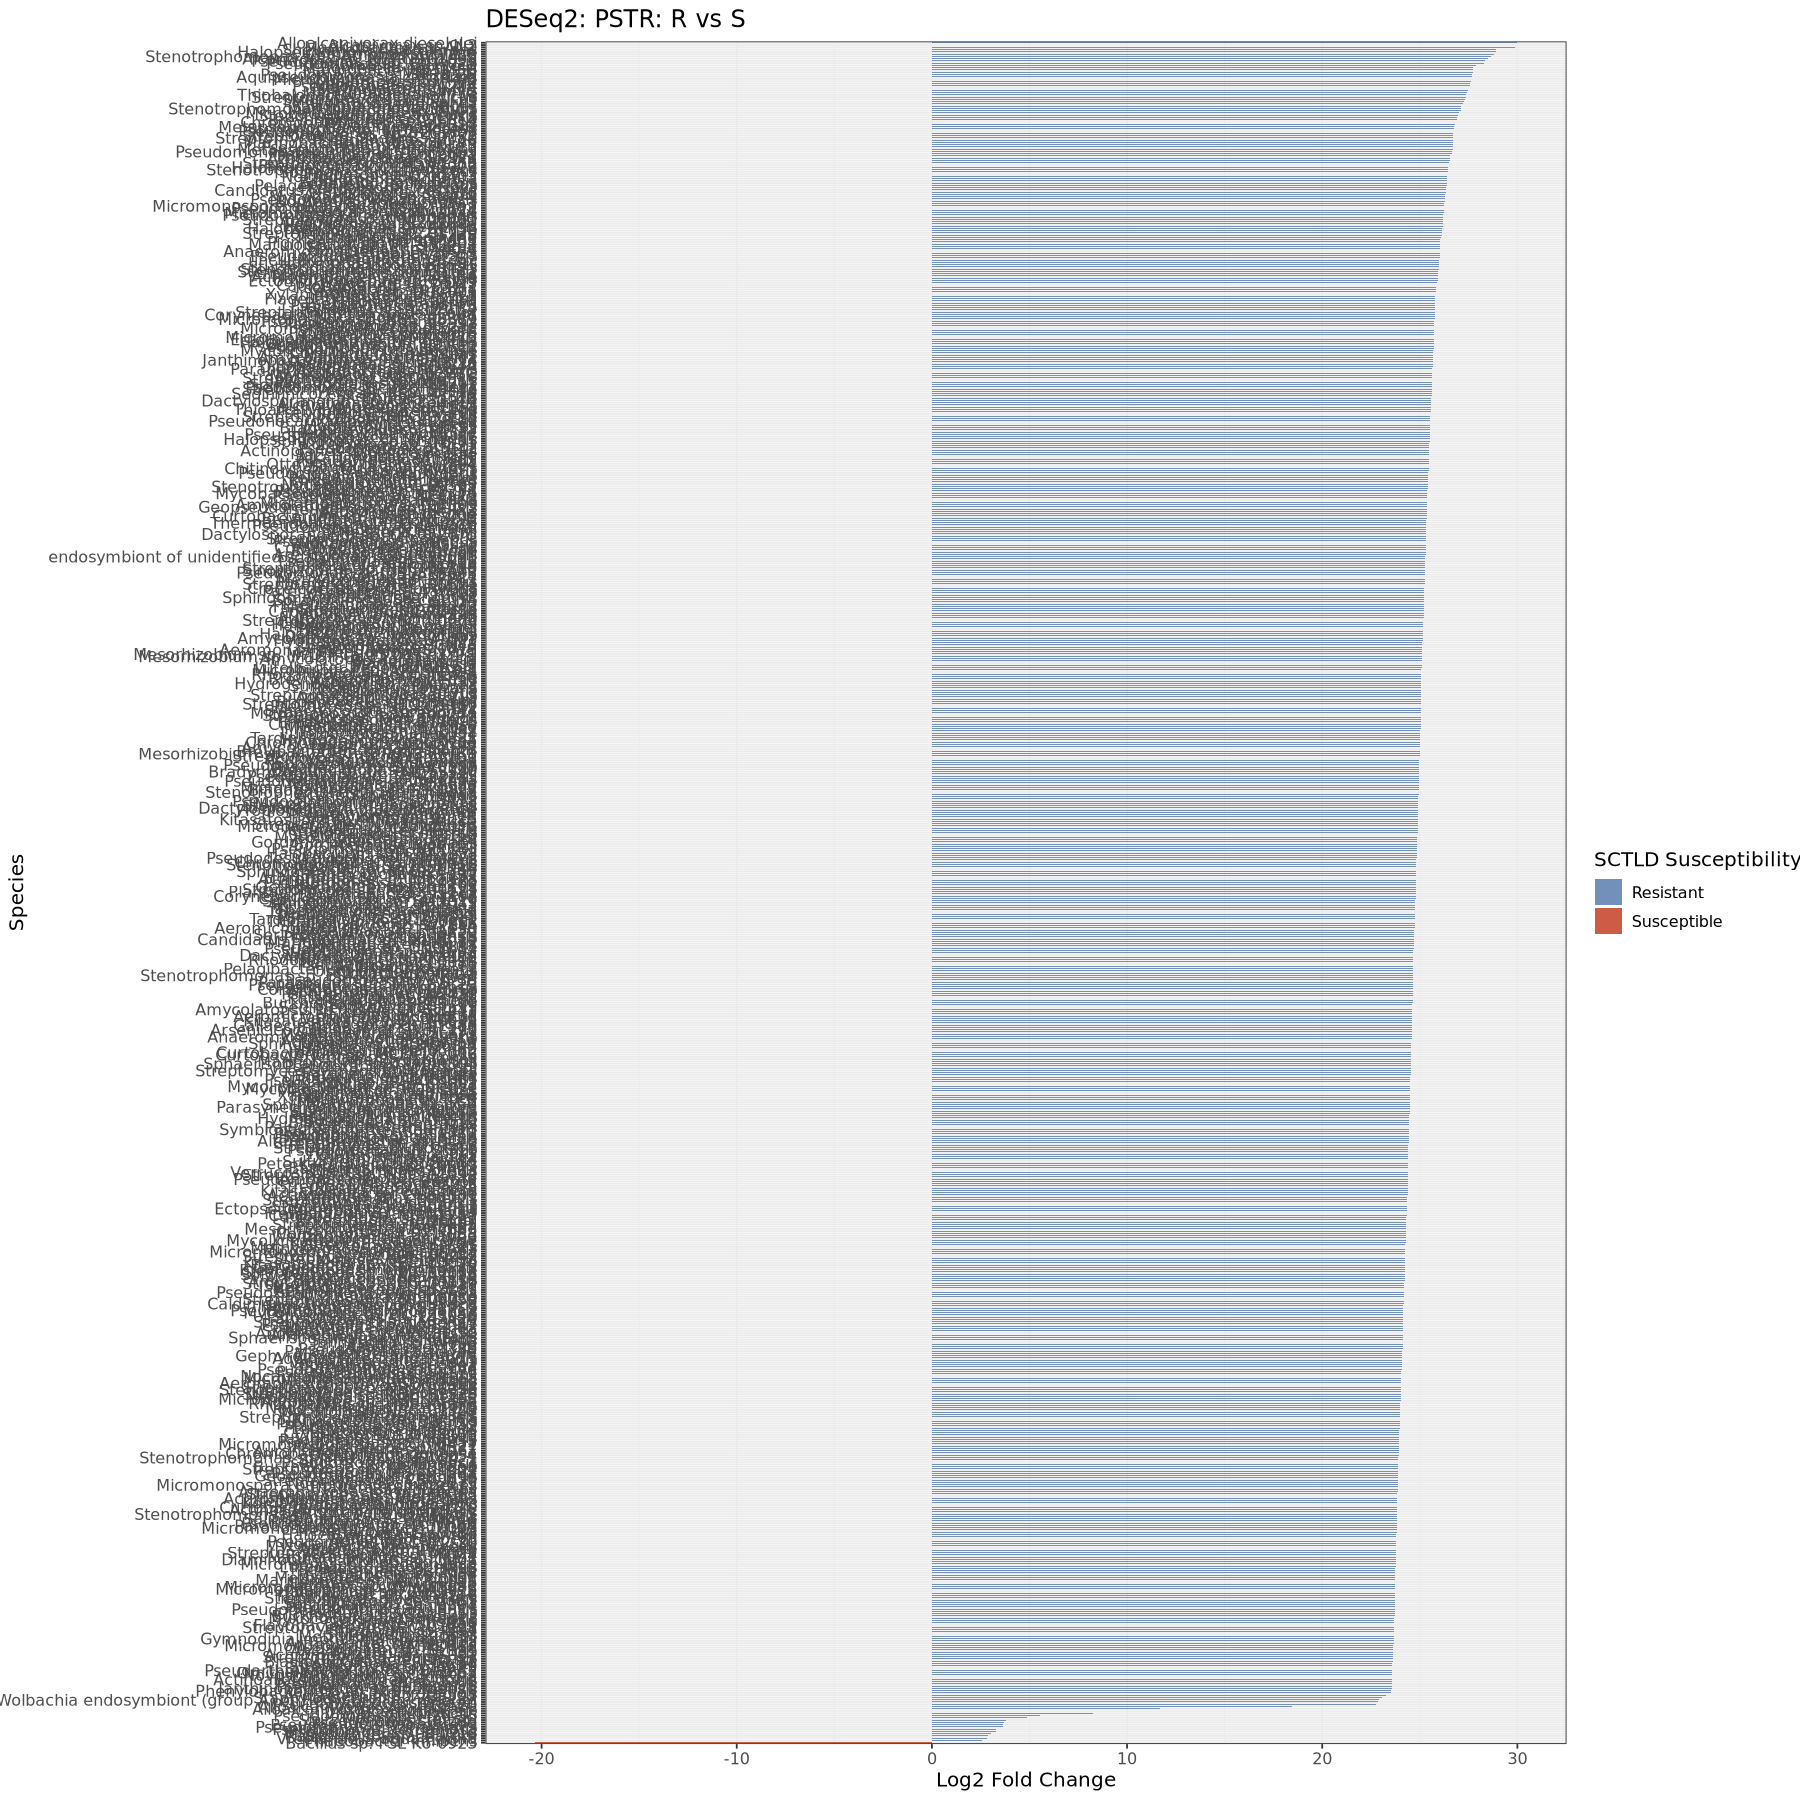

In [126]:
pstr_res<-view_ds_res(pstr_ds, "RS","Resistant","Susceptible")

# plot significantly different OTUs 
ggplot(pstr_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="#7290ba", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: PSTR: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 12)) 

In [127]:
pstr_ps_genus

ERROR: Error: object 'pstr_ps_genus' not found


In [ ]:
# genus level
pstr_ps_genus<- subset_samples(ps_genus, Species == "PSTR")

pstr_rs = phyloseq_to_deseq2(pstr_ps_genus, ~ RS)
pstr_rs = DESeq(pstr_rs, test="Wald", fitType="parametric")
res = results(pstr_rs, cooksCutoff = FALSE, contrast=c("RS", "Resistant", "Susceptible"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_pstr_g = cbind(as(sigtab_a, "data.frame"), as(tax_table(pstr_ps_genus)[rownames(sigtab_a), ], "matrix"))

In [ ]:
mcav_genus_res<-view_ds_res(genus_mcav_ds, "RS","Resistant","Susceptible")

# plot significantly different OTUs 
ggplot(mcav_genus_res, aes(x = reorder(genus,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: MCAV genera: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 12)) 

In [ ]:
# group pstr and mcav results and plot together 

sigtab_mcav$coral_spp <- "MCAV"
pstr_res$coral_spp <- "PSTR"
pstr_mcav_res<-rbind(sigtab_mcav, pstr_res)

In [ ]:
ggplot(pstr_mcav_res, aes(x = species, y = log2FoldChange, fill = coral_spp)) +
    geom_bar(stat = "identity", width = 0.4) +
    facet_wrap(~coral_spp)+
    coord_flip() + 
    scale_fill_manual(values= custom_list)+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: PSTR: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 12)) 

In [ ]:
ggplot(pstr_mcav_res, aes(x = species, y = log2FoldChange, fill = coral_spp)) +
    geom_bar(stat = "identity", width = 0.4) +
    # facet_wrap(~coral_spp)+
    coord_flip() + 
    scale_fill_manual(values= custom_list)+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: PSTR: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 12)) 

In [ ]:
# past
past_ps<- subset_samples(RS_ps, Species == "PAST")

past_ds<-run_deseq(past_ps, "RS","Resistant","Susceptible")

In [ ]:
past_res<-view_ds_res(past_ds, "RS","Resistant","Susceptible")

# plot significantly different OTUs 
ggplot(past_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = RS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Resistant"="cyan3", "Susceptible"="coral3"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: PAST: R vs S", fill = "SCTLD Susceptibility")+
    theme(text = element_text(size = 12)) 

In [ ]:
# do orbis 2022 healthy and diseased tissue r vs s??

In [ ]:
# do mmea healthy (sus) vs all other resis spp? 

### DESeq2 Disease vs Healthy

In [ ]:
# all specie comparisons: healthy vs disease
dis_all_ds = phyloseq_to_deseq2(sctld_raw2, ~ Health_status)
dis_all_ds = DESeq(dis_all_ds, test="Wald", fitType="parametric")
res = results(dis_all_ds, cooksCutoff = FALSE, contrast=c("Health_status", "Healthy", "Diseased_Margin"))
alpha = 0.00001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab_a, "data.frame"), as(tax_table(sctld_raw2)[rownames(sigtab_a), ], "matrix"))

In [ ]:
# sort by most significant 
sigtab_hs <- sigtab_mcav %>%
  arrange(padj)%>%
# add R vs S col
    mutate(HS = if_else(log2FoldChange<0, "Diseased_Margin","Healthy"))
head(sigtab_hs)
dim(sigtab_hs)

In [ ]:
# plot significantly different OTUs
ggplot(sigtab_hs, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = HS)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Healthy"="darkseagreen4", "Diseased_Margin"="firebrick"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: All Species: Healthy vs Disease Margin", fill = "Health Status")+
    theme(text = element_text(size = 16)) 

In [ ]:
# disease margin vs disease tissue
dm_dt_ds<-run_deseq(phylo_obj = sctld_raw2, comparison = "Health_status", contrast1 = "Diseased_Tissue",contrast2 = "Diseased_Margin")

In [ ]:
dm_dt_res<-view_ds_res(dm_dt_ds, comparison = "Health_status", contrast1 = "Diseased_Tissue",contrast2 = "Diseased_Margin")

# plot significantly different OTUs
ggplot(dm_dt_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = Health_status)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Diseased_Tissue"="lightsalmon2", "Diseased_Margin"="firebrick"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: All Species: Disease Tissue vs Disease Margin", fill = "Health Status")+
    theme(text = element_text(size = 16)) 

In [ ]:
# search for disease margin sig diff taxa in all disease samples
# youre deffs supposed to use kraken uniq for this 

In [ ]:
sctld_assoc_otus<-rownames(dm_dt_res)

In [ ]:
# otu_table %>%
#     filter(rownames %in% sctld_assoc_otus)

In [ ]:
sctld_assoc_taxa<-unique(dm_dt_res$species)

In [ ]:
# disease tissue vs healthy
hdt_ds<-run_deseq(phylo_obj = sctld_raw2, comparison = "Health_status", contrast1 = "Healthy",contrast2 = "Diseased_Tissue")

hdt_res<-view_ds_res(hdt_ds, comparison = "Health_status", contrast1 = "Healthy",contrast2 = "Diseased_Tissue")

# plot significantly different OTUs
ggplot(hdt_res, aes(x = reorder(species,log2FoldChange), y = log2FoldChange, fill = Health_status)) +
    geom_bar(stat = "identity", width = 0.4) +
    coord_flip() + 
    scale_fill_manual(values= c("Healthy"="darkseagreen4", "Diseased_Tissue"="lightsalmon2"))+
    theme_bw()+
    labs(x = "Species", y = "Log2 Fold Change", title = "DESeq2: All Species: Healthy vs Disease Tissue", fill = "Health Status")+
    theme(text = element_text(size = 16)) 

In [ ]:
## try within species comparisons too 

### Taxa Bar Plots

In [ ]:
# subset taxa and normalzie out of 100 - species level
sctld_raw_10 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:10]), sctld_raw)
sctld_raw_10_norm <- transform_sample_counts(sctld_raw_10, function(x) x / sum(x))
     
sctld_raw_30 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:30]), sctld_raw)
sctld_raw_30_norm <- transform_sample_counts(sctld_raw_30, function(x) x / sum(x))

sctld_raw_100 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:100]), sctld_raw)
sctld_raw_100_norm <- transform_sample_counts(sctld_raw_100, function(x) x / sum(x))

In [ ]:
# subset genus level - 30 and 100 

top30<-names(sort(taxa_sums(ps_genus), decreasing = TRUE))[1:30]
ps30_genus <-prune_taxa(top30, ps_genus)
ps30_genus_norm <- transform_sample_counts(ps30_genus, function(x) x / sum(x))

# top 100 genera
top100<-names(sort(taxa_sums(ps_genus), decreasing = TRUE))[1:100]
ps100_genus <-prune_taxa(top100, ps_genus)
ps100_gnorm <- transform_sample_counts(ps100_genus, function(x) x / sum(x))

In [ ]:
length(unique(tax_table(ps30_genus_norm)[,"genus"]))
length(unique(tax_table(ps30_genus_norm)[,"species"]))

In [ ]:
g_colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )

In [ ]:
# map list of 100 genera to same color
top100_names <- as.character(tax_table(ps100_genus)[, "genus"])
names(g_colors) <- top100_names
head(g_colors)

In [ ]:
options(repr.plot.height = 15, repr.plot.width = 30)

In [ ]:
plot_bar(ps30_genus_norm,x = "Sample",fill='genus')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# all samples - top 30 genera

#### 2019 only

In [ ]:
# try just each spp R vs S in 2019

sctld_100_2019<- subset_samples(sctld_raw, year == "2019")
sctld_100_2019 = prune_taxa(names(sort(taxa_sums(sctld_100_2019),TRUE)[1:100]), sctld_100_2019)
sctld_100_2019_norm <- transform_sample_counts(sctld_100_2019, function(x) x / sum(x))

In [ ]:
# map list of 100 species to same color
top100_s <- as.character(tax_table(sctld_100_2019)[, "species"])
names(colors) <- top100_s
head(colors)

In [ ]:
plot_bar(sctld_100_2019_norm,x = "Sample",fill='species')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# found the PSTR outlier 

# 2019: Top 100 OTUs (species)

In [ ]:
# top 30 at genus level
ps_genus2019<-tax_glom(sctld_100_2019, taxrank = "genus")
top30<-names(sort(taxa_sums(ps_genus2019), decreasing = TRUE))[1:30]
ps30_g2019 <-prune_taxa(top30, ps_genus2019)
ps30_g2019_norm <- transform_sample_counts(ps30_g2019, function(x) x / sum(x))

In [ ]:
# add new taxa to colors list (to keep the rest consistent)
# names of these top 30 genus
genera_2019 <- as.character(tax_table(ps30_g2019)[, "genus"])
missing_genera <- setdiff(genera_2019, names(g_colors))

# add new colors
new_colors <- colorRampPalette(brewer.pal(8, "Dark2"))(length(missing_genera))
names(new_colors) <- missing_genera
  
# append to colors vector
g_colors <- c(g_colors, new_colors)
missing_genera

In [ ]:
# view colors
# barplot(rep(1, length(new_colors)), 
#         col = new_colors, 
#         names.arg = names(new_colors), 
#         las = 2, 
#         border = NA,
#         main = "Genus Color Map")

In [ ]:
plot_bar(ps30_g2019_norm,x = "Sample",fill='genus')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# found the PSTR outlier 
# top 30 genera 2019 only 

In [ ]:
# plot each spp individually...

##### MCAV --------------------------------------------------------------------------------

In [ ]:
library(ggh4x)

In [ ]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [ ]:
# looking just at mcav, remove disease margin

subset_mcav<- subset_samples(sctld_raw, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))

# top 100 species
mcav_100 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:100]), subset_mcav)
mcav_100_norm <- transform_sample_counts(mcav_100, function(x) x / sum(x))

mcav_30 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:30]), subset_mcav)
mcav_30_norm <- transform_sample_counts(mcav_30, function(x) x / sum(x))

# top 30 genera
mcav_g<- subset_samples(ps30_genus_norm, (Species == "MCAV" & Health_status != "Diseased_Margin"))
mcav_g<- subset_samples(mcav_g, (!(Date_InitialTag %in% dec_tags)))

# repeat top 30 spp 
mcav_s<- subset_samples(sctld_raw_30_norm, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
mcav_s<- subset_samples(mcav_s, (!(Date_InitialTag %in% dec_tags)))

In [ ]:
df_meta <- data.frame(sample_data(subset_mcav))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_mcav) <- sample_data(df_meta)

In [ ]:
library(patchwork)

In [ ]:
# reorder colonies
mcav_g_S<-subset_samples(mcav_g, RS == "Susceptible")
df_meta<-data.frame(sample_data(mcav_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(mcav_g_S)$colony_id <-
  factor(sample_data(mcav_g_S)$colony_id, levels = col_order)

In [ ]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(mcav_g, RS == "Resistant"),x = "month_year", fill = "genus")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant MCAV (genus)")
p_S <- plot_bar(mcav_g_S,x = "month_year", fill = "genus") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible MCAV (genus)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "MCAV colonies") &
  theme(legend.position = "right")

In [ ]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_g,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 genus - R vs S. individuals over time 

In [ ]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"

p<-plot_bar(mcav_100_norm,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (species)

In [ ]:
# top 30 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_30_norm,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 OTUs (species)

In [ ]:
# repeat for species level 
# repeat for family level

In [ ]:
# repeat other spp 

##### PSTR --------------------------------------------------------------------------------

In [ ]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [ ]:
# looking just at PSTR, remove disease margin

subset_PSTR<- subset_samples(sctld_raw, (Species == "PSTR" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PSTR<- subset_samples(subset_PSTR, (!(Date_InitialTag %in% dec_tags)))

# top 100 species
PSTR_100 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:100]), subset_PSTR)
PSTR_100_norm <- transform_sample_counts(PSTR_100, function(x) x / sum(x))

PSTR_30 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:30]), subset_PSTR)
PSTR_30_norm <- transform_sample_counts(PSTR_30, function(x) x / sum(x))

# top 30 genera
PSTR_g<- subset_samples(ps30_genus_norm, (Species == "PSTR" & Health_status != "Diseased_Margin"))
PSTR_g<- subset_samples(PSTR_g, (!(Date_InitialTag %in% dec_tags)))

# repeat top 30 spp 
PSTR_s<- subset_samples(sctld_raw_30_norm, (Species == "PSTR" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
PSTR_s<- subset_samples(PSTR_s, (!(Date_InitialTag %in% dec_tags)))

In [ ]:
df_meta <- data.frame(sample_data(subset_PSTR))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PSTR) <- sample_data(df_meta)

In [ ]:
# reorder colonies
PSTR_g_S<-subset_samples(PSTR_g, RS == "Susceptible")
df_meta<-data.frame(sample_data(PSTR_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(PSTR_g_S)$colony_id <-
  factor(sample_data(PSTR_g_S)$colony_id, levels = col_order)

In [ ]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(PSTR_g, RS == "Resistant"),x = "month_year", fill = "genus")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant PSTR (genus)")
p_S <- plot_bar(PSTR_g_S,x = "month_year", fill = "genus") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible PSTR (genus)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "PSTR colonies") &
  theme(legend.position = "right")

In [ ]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_g,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 genus - R vs S. individuals over time 

In [ ]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"

p<-plot_bar(PSTR_100_norm,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (species)

In [ ]:
# top 30 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_30_norm,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 OTUs (species)

##### MMEA --------------------------------------------------------------------------------

In [ ]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [ ]:
# looking just at MMEA, remove disease margin

subset_MMEA<- subset_samples(sctld_raw, (Species == "MMEA"))

# top 100 species
MMEA_100 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:100]), subset_MMEA)
MMEA_100_norm <- transform_sample_counts(MMEA_100, function(x) x / sum(x))

MMEA_30 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:30]), subset_MMEA)
MMEA_30_norm <- transform_sample_counts(MMEA_30, function(x) x / sum(x))

# top 30 genera
MMEA_g<- subset_samples(ps30_genus_norm, (Species == "MMEA"))

# repeat top 30 spp 
MMEA_s<- subset_samples(sctld_raw_30_norm, (Species == "MMEA"))

In [ ]:
df_meta <- data.frame(sample_data(subset_MMEA))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_MMEA) <- sample_data(df_meta)

In [ ]:
# reorder colonies
MMEA_g_S<-subset_samples(MMEA_g, RS == "Susceptible")
df_meta<-data.frame(sample_data(MMEA_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(MMEA_g_S)$colony_id <-
  factor(sample_data(MMEA_g_S)$colony_id, levels = col_order)

In [ ]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_S <- plot_bar(MMEA_g_S,x = "month_year", fill = "genus") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible MMEA (genus)")
p_S

In [ ]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_g,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 genus - R vs S. individuals over time 

In [ ]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"

p<-plot_bar(MMEA_100_norm,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (species)

In [ ]:
# top 30 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_30_norm,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 OTUs (species)

##### PAST --------------------------------------------------------------------------------

In [ ]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [ ]:
# looking just at PAST, remove disease margin

subset_PAST<- subset_samples(sctld_raw, (Species == "PAST" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PAST<- subset_samples(subset_PAST, (!(Date_InitialTag %in% dec_tags)))

# top 100 species
PAST_100 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:100]), subset_PAST)
PAST_100_norm <- transform_sample_counts(PAST_100, function(x) x / sum(x))

PAST_30 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:30]), subset_PAST)
PAST_30_norm <- transform_sample_counts(PAST_30, function(x) x / sum(x))

# top 30 genera
PAST_g<- subset_samples(ps30_genus_norm, (Species == "PAST" & Health_status != "Diseased_Margin"))
PAST_g<- subset_samples(PAST_g, (!(Date_InitialTag %in% dec_tags)))

# repeat top 30 spp 
PAST_s<- subset_samples(sctld_raw_30_norm, (Species == "PAST" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
PAST_s<- subset_samples(PAST_s, (!(Date_InitialTag %in% dec_tags)))

In [ ]:
df_meta <- data.frame(sample_data(subset_PAST))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PAST) <- sample_data(df_meta)

In [ ]:
# reorder colonies
PAST_g_S<-subset_samples(PAST_g, RS == "Susceptible")
df_meta<-data.frame(sample_data(PAST_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(PAST_g_S)$colony_id <-
  factor(sample_data(PAST_g_S)$colony_id, levels = col_order)

In [ ]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(PAST_g, RS == "Resistant"),x = "month_year", fill = "genus")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant PAST (genus)")
p_S <- plot_bar(PAST_g_S,x = "month_year", fill = "genus") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible PAST (genus)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "PAST colonies") &
  theme(legend.position = "right")

In [ ]:
# "resistant" colonies that don't have 2022 data 
colony %>%
    filter(colony_id == "T2_47_PAST" | colony_id == "T3_13_PAST") %>%
    select(colony_id, X122022_Condition, X092023_Condition, X012024_Condition, X042024_Condition)
# t3 13 was found again and sampled as healthy in 4/2024, looks like just missed the sample but we have healthy documented in 122022
# remove t2 47 - next sample in 6/2025 and I'm not convinced its the same colony 
# SUS T2 347 was Dead in 05/2022

In [ ]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_g,x = "month_year",fill='genus')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=genus), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 genus - R vs S. individuals over time 

In [ ]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"

p<-plot_bar(PAST_100_norm,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (species)

In [ ]:
# top 30 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_30_norm,x = "month_year",fill='species')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=species), stat="identity",position="stack")+
    scale_fill_manual(values = colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 OTUs (species)